# EDA — `datasets_deepseek_gullibility_v1`

A comprehensive exploratory pass over the **raw v1 release**: 29,621 synthetic
`HUMAN:` / `ASSISTANT:` conversations generated by `deepseek/deepseek-v4-pro-0813` with
[`src/generate.seegull.v0.3.data.py`](../../src/generate.seegull.v0.3.data.py), where the user
is either **high** or **low** gullibility.

This notebook reads the archive directly (`datasets_deepseek_gullibility_v1.zip`, no
extraction needed) and is meant to be read together with the two earlier analyses:

* [`nb/eda.ipynb`](../eda.ipynb) — EDA of raw **v0.3**
* [`gullibility-corpus-audit.html`](../../gullibility-corpus-audit.html) — audit of **v0.3 deduped**

It repeats the checks that mattered for v0.3 (the `?` shortcut, generator templates,
length confound, assistant-side signal, near-duplicates) and adds what is new in v1: a much
longer multi-run generation, degenerate repetition inside large calls, and overlap with the
v0.3 release that the current probe was trained and evaluated on.

### TL;DR

The files are structurally clean: every transcript alternates correctly, metadata matches the
text, and there are no index gaps. **As a training set, though, v1 has five problems, and the
first two are serious.**

| # | Finding | Size | Consequence |
|---|---|---|---|
| 1 | **All of v0.3 is inside v1, verbatim, including all 842 holdout conversations** | 3,993 rows | A probe trained on v1 and scored on the v0.3 holdout is scored on its own training data |
| 2 | **Generation loops**: large calls re-emit the same conversations over and over | 4,252 exact copies (14.4%), up to 32 copies of one transcript | Inflates counts and biases any mean-difference direction toward a few looped stories |
| 3 | **The `?` shortcut is still there**: counting `?` in user turns gives AUC 0.981 | 55% of high vs 0.9% of low have no `?` | Any probe needs to beat ~0.98, not 0.5 |
| 4 | **Imbalance comes from 13 low-only top-up calls**; mixed calls are 49.8% high | +4,446 low | Downsample, or drop the top-up calls |
| 5 | **Topic and length are confounded with level**: high skews toward pseudo-science topics (topic label alone gives AUC 0.66); assistant replies are longer for low (d = −0.78) | — | Part of the signal is subject matter and assistant verbosity, not the user trait |

After dropping loop copies, near-duplicates, v0.3 overlap and explicit label words, and
balancing, roughly **15–18k conversations** remain, about 4–4.5× v0.3 rather than the 7.4× in
the README. Details and the projected cleaning funnel are in §18, and recommendations in §19.

In [1]:
from __future__ import annotations

import collections
import hashlib
import json
import re
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)


def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "datasets_deepseek_gullibility_v1.zip").exists():
            return p
    raise FileNotFoundError("datasets_deepseek_gullibility_v1.zip not found above " + str(start))


ROOT = find_repo_root(Path.cwd())
V1_ZIP = ROOT / "datasets_deepseek_gullibility_v1.zip"
V03_ZIP = ROOT / "datasets_deepseek_gullibility_v0_3.deduped.3992.zip"
OUT = Path.cwd() / "eda_v1_outputs"
OUT.mkdir(exist_ok=True)

LEVELS = ["low", "high"]
SEED = 0

# Chart style: two validated categorical slots for the levels, neutral ink for everything else.
LVL_COLORS = {"low": "#2a78d6", "high": "#eb6834"}
INK, INK2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
NEUTRAL = "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "text.color": INK,
    "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"],
})


def banner(title: str) -> None:
    print("=" * 78)
    print(title)
    print("=" * 78)


def auc_dir(y, score) -> tuple[float, str]:
    """Single-feature AUC, reported as the separating strength plus which class scores higher."""
    a = roc_auc_score(y, score)
    return (a, "high>low") if a >= 0.5 else (1 - a, "low>high")


def cohens_d(a, b) -> float:
    a, b = np.asarray(a, float), np.asarray(b, float)
    s = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / s


print("repo root :", ROOT)
print("v1 zip    :", V1_ZIP.name, f"{V1_ZIP.stat().st_size / 1e6:.1f} MB")
print("outputs   :", OUT)

repo root : D:\Projects\SeeGULL
v1 zip    : datasets_deepseek_gullibility_v1.zip 33.6 MB
outputs   : D:\Projects\SeeGULL\nb\EDA\eda_v1_outputs


## 1. Load & parse

Each conversation is a `conversation_<i>_gullibility_<level>.txt` transcript plus a `.json`
metadata file. Everything is read straight from the zip. Two frames are built:

* **`conv`**: one row per conversation (metadata plus text statistics)
* **`turns`**: one row per turn

In [2]:
PFX = "datasets_deepseek_gullibility_v1/"
STEM_RE = re.compile(r"^conversation_(\d+)_gullibility_(high|low)\.(txt|json)$")
TURN_RE = re.compile(r"^(HUMAN|ASSISTANT):\s?(.*)$")

zf = zipfile.ZipFile(V1_ZIP)
files = collections.defaultdict(dict)
aux_files = []
for name in zf.namelist():
    base = name[len(PFX):]
    if not base:
        continue
    m = STEM_RE.match(base)
    if m:
        files[base.rsplit(".", 1)[0]][m.group(3)] = name
    else:
        aux_files.append((base, zf.getinfo(name).file_size))

rows, turn_rows = [], []
for stem, fs in files.items():
    meta = json.loads(zf.read(fs["json"])) if "json" in fs else {}
    text = zf.read(fs["txt"]).decode("utf-8") if "txt" in fs else ""
    parsed, orphan = [], 0
    for line in text.splitlines():
        m = TURN_RE.match(line)
        if m:
            parsed.append(["user" if m.group(1) == "HUMAN" else "assistant", m.group(2)])
        elif parsed:
            parsed[-1][1] += "\n" + line
            orphan += 1
        else:
            orphan += 1
    rows.append({"stem": stem, "has_json": "json" in fs, "has_txt": "txt" in fs,
                 "meta_keys": tuple(sorted(meta)), "orphan_lines": orphan,
                 "turn_list": parsed, "full_text": text, **meta})

conv = pd.DataFrame(rows)
conv["t"] = pd.to_datetime(conv["generated_at"], utc=True)
conv = conv.sort_values("t", kind="stable").reset_index(drop=True)

# `call_index` restarts at 1 in every resumed run, and each run used its own seed,
# so (run, call_index) is the real batch key.
run_order = conv.groupby("seed")["t"].min().sort_values().index
RUN_OF_SEED = {s: i + 1 for i, s in enumerate(run_order)}
conv["run"] = conv["seed"].map(RUN_OF_SEED)
conv["call_key"] = conv.apply(lambda r: f"r{r.run}c{r.call_index:03d}", axis=1)
call_order = conv.groupby("call_key")["t"].min().sort_values().index
conv["call_seq"] = conv["call_key"].map({k: i + 1 for i, k in enumerate(call_order)})

conv["user_turns"] = conv["turn_list"].map(lambda t: [x for r, x in t if r == "user"])
conv["asst_turns"] = conv["turn_list"].map(lambda t: [x for r, x in t if r == "assistant"])
conv["user_text"] = conv["user_turns"].map("\n".join)
conv["asst_text"] = conv["asst_turns"].map("\n".join)
conv["n_turns"] = conv["turn_list"].map(len)
conv["n_user_turns"] = conv["user_turns"].map(len)
conv["n_asst_turns"] = conv["asst_turns"].map(len)
conv["user_words"] = conv["user_text"].str.split().map(len)
conv["asst_words"] = conv["asst_text"].str.split().map(len)
conv["total_words"] = conv["user_words"] + conv["asst_words"]
conv["ends_with_user"] = conv["turn_list"].map(lambda t: t[-1][0] == "user")
conv["user_q"] = conv["user_text"].str.count(r"\?")
conv["user_excl"] = conv["user_text"].str.count("!")
conv["user_commit"] = conv["user_text"].str.count(r"(?i)\b(?:I'll|I will|I'm going to|I am going to|I'm gonna)\b")
conv["first_user"] = conv["user_turns"].map(lambda t: t[0] if t else "")
conv["last_user"] = conv["user_turns"].map(lambda t: t[-1] if t else "")
conv["y"] = (conv["level"] == "high").astype(int)

for c in conv.itertuples():
    for pos, (role, text) in enumerate(c.turn_list):
        turn_rows.append((c.stem, c.level, c.call_key, pos, role, text))
turns = pd.DataFrame(turn_rows, columns=["stem", "level", "call_key", "pos", "role", "text"])
turns["role_pos"] = turns.groupby(["stem", "role"]).cumcount()
turns["n_words"] = turns["text"].str.split().map(len)
turns["n_q"] = turns["text"].str.count(r"\?")

print(f"conversations : {len(conv):,}")
print(f"turns         : {len(turns):,}  ({(turns.role == 'user').sum():,} user / {(turns.role == 'assistant').sum():,} assistant)")
print(f"words         : {conv.total_words.sum():,}")
print(f"runs          : {conv.run.nunique()}   calls: {conv.call_key.nunique()}")
conv[["stem", "level", "topic", "run", "call_index", "n_turns", "user_words", "asst_words", "user_q"]].head()

conversations : 29,621
turns         : 179,446  (91,176 user / 88,270 assistant)
words         : 3,260,558
runs          : 3   calls: 137


,stem,level,topic,run,call_index,n_turns,user_words,asst_words,user_q
0,conversation_0_gullibility_low,low,Running form and knee pain,1,1,6,57,82,2
1,conversation_0_gullibility_high,high,Vitamin D and immunity,1,1,6,47,62,2
2,conversation_1_gullibility_low,low,Rental deposit return,1,1,6,40,62,3
3,conversation_1_gullibility_high,high,Credit score myth about checking,1,1,6,37,44,2
4,conversation_2_gullibility_low,low,Car oil change interval,1,1,6,54,63,4


## 2. Inventory & integrity

Is the archive complete and well-formed? This checks file pairing, schema, index coverage
and the structural rules enforced by the generator's `validate_conversation()`.

In [3]:
banner("ARCHIVE INVENTORY")
print(f"  conversation stems        : {len(files):,}")
print(f"  .json without .txt        : {(~conv.has_txt).sum()}")
print(f"  .txt without .json        : {(~conv.has_json).sum()}")
print("  auxiliary files           :")
for name, size in aux_files:
    print(f"      {name:<20} {size:>10,} bytes")
print(f"  distinct metadata schemas : {conv.meta_keys.nunique()}  -> {list(conv.meta_keys.iloc[0])}")
print(f"  attribute values          : {conv.attribute.unique().tolist()}")
print(f"  model values              : {conv.model.unique().tolist()}")

banner("INDEX COVERAGE  (index is a per-level counter, not a pair id)")
for lv in LEVELS:
    idx = conv.loc[conv.level == lv, "index"]
    missing = set(range(idx.max() + 1)) - set(idx)
    print(f"  {lv:<5} n={len(idx):>6,}  range {idx.min()}..{idx.max()}  gaps={len(missing)}  dup indices={idx.duplicated().sum()}")

pair_topics = conv.pivot_table(index="index", columns="level", values="topic", aggfunc="first").dropna()
same_topic_pairs = (pair_topics["high"].str.lower() == pair_topics["low"].str.lower()).mean()
print(f"  same index, same topic across levels: {same_topic_pairs:.1%} of {len(pair_topics):,} shared indices")

banner("STRUCTURAL VALIDITY")
alternates = conv.turn_list.map(lambda t: all(r == ("user" if i % 2 == 0 else "assistant") for i, (r, _) in enumerate(t)))
empty_turns = conv.turn_list.map(lambda t: sum(1 for _, x in t if not x.strip()))
print(f"  strictly alternating, user first : {alternates.sum():,} / {len(conv):,}")
print(f"  metadata num_turns == parsed     : {(conv.num_turns == conv.n_turns).sum():,} / {len(conv):,}")
print(f"  orphan (untagged) lines          : {conv.orphan_lines.sum()}")
print(f"  empty turns                      : {empty_turns.sum()}")
print(f"  >= 3 user and >= 2 assistant     : {((conv.n_user_turns >= 3) & (conv.n_asst_turns >= 2)).sum():,}")
print(f"  ends on a USER turn              : {conv.ends_with_user.sum():,} ({conv.ends_with_user.mean():.1%})")
nonascii = conv.full_text.map(lambda s: any(ord(ch) > 127 for ch in s))
print(f"  transcripts with non-ASCII chars : {nonascii.sum():,} ({nonascii.mean():.1%})")

ARCHIVE INVENTORY
  conversation stems        : 29,621
  .json without .txt        : 0
  .txt without .json        : 0
  auxiliary files           :
      run.pid                       6 bytes
      run.log                   9,935 bytes
      spend_log.jsonl          15,655 bytes
      run2.log                  8,622 bytes
      run3.log                852,942 bytes
  distinct metadata schemas : 1  -> ['attribute', 'call_index', 'generated_at', 'index', 'leak_stems_found', 'level', 'model', 'num_turns', 'seed', 'topic']
  attribute values          : ['gullibility']
  model values              : ['deepseek/deepseek-v4-pro-0813']
INDEX COVERAGE  (index is a per-level counter, not a pair id)
  low   n=16,955  range 0..16954  gaps=0  dup indices=0
  high  n=12,666  range 0..12665  gaps=0  dup indices=0
  same index, same topic across levels: 0.0% of 12,666 shared indices
STRUCTURAL VALIDITY
  strictly alternating, user first : 29,621 / 29,621
  metadata num_turns == parsed     : 29,621 / 2

  transcripts with non-ASCII chars : 1,657 (5.6%)


## 3. Checking the README's v1 claims

The README's *v1 at a glance* table was produced by a quick pass. Each figure is recomputed here.

In [4]:
turn_share_6 = (conv.n_turns == 6).mean()
claims = [
    ("Conversations", "29,621", f"{len(conv):,}"),
    ("Low / high", "16,955 / 12,666", f"{(conv.level == 'low').sum():,} / {(conv.level == 'high').sum():,}"),
    ("Class share low / high", "57.2 / 42.8", f"{(conv.level == 'low').mean():.1%} / {(conv.level == 'high').mean():.1%}"),
    ("Generator", "deepseek/deepseek-v4-pro-0813", ", ".join(conv.model.unique())),
    ("Distinct topics", "16,414", f"{conv.topic.nunique():,} (case/space-normalised: {conv.topic.str.lower().str.strip().nunique():,})"),
    ("Turns == 6", "89%", f"{turn_share_6:.1%}"),
    ("Turn range", "5-10", f"{conv.n_turns.min()}-{conv.n_turns.max()}"),
    ("Words median / mean", "111 / 116", f"{conv.total_words.median():.0f} / {conv.total_words.mean():.0f}"),
    ("Words range", "34-516", f"{conv.total_words.min()}-{conv.total_words.max()}"),
    ("Median words low / high", "118 / 102", f"{conv.loc[conv.level=='low','total_words'].median():.0f} / {conv.loc[conv.level=='high','total_words'].median():.0f}"),
    ("Generated", "2026-09-11 -> 2026-09-12", f"{conv.t.min():%Y-%m-%d %H:%M} -> {conv.t.max():%Y-%m-%d %H:%M} UTC"),
    ("Deduplicated / leak-checked", "No", f"{conv.full_text.duplicated().sum():,} exact duplicate transcripts present"),
]
pd.DataFrame(claims, columns=["README claim", "README value", "observed"]).set_index("README claim")

,README value,observed
README claim,,
Conversations,"29,621","29,621"
Low / high,"16,955 / 12,666","16,955 / 12,666"
Class share low / high,57.2 / 42.8,57.2% / 42.8%
Generator,deepseek/deepseek-v4-pro-0813,deepseek/deepseek-v4-pro-0813
Distinct topics,"16,414","16,414 (case/space-normalised: 16,280)"
Turns == 6,89%,88.9%
Turn range,5-10,5-10
Words median / mean,111 / 116,105 / 110
Words range,34-516,28-510


### Reading 3

Every count in the README reproduces: size, class split, topics, turn distribution, dates. The
word counts are 5–6 lower than the README's because the README counted the `HUMAN:` /
`ASSISTANT:` role tags as words (6 per conversation). The one real correction is the last row.
"Not deduplicated" understates the problem: 4,252 of the 29,621 files are exact copies of
another file (§6).

## 4. Provenance: runs, calls, spend and logs

The generator writes into one directory and resumes when restarted. The archive holds three
run logs, a spend ledger and the `generated_at`, `seed` and `call_index` of every conversation,
which is enough to reconstruct how the corpus was produced.

In [5]:
banner("RUNS  (one seed per run; call_index restarts in each)")
runs = conv.groupby("run").agg(
    seed=("seed", "first"), n=("stem", "size"), calls=("call_key", "nunique"),
    high_share=("y", "mean"), start=("t", "min"), end=("t", "max"),
)
runs["hours"] = (runs.end - runs.start).dt.total_seconds() / 3600
print(runs.to_string(formatters={"high_share": "{:.1%}".format, "hours": "{:.1f}".format}))

calls = conv.groupby("call_key").agg(
    run=("run", "first"), call_seq=("call_seq", "first"), n=("stem", "size"),
    n_low=("level", lambda s: (s == "low").sum()), n_high=("y", "sum"),
    start=("t", "min"), end=("t", "max"),
).sort_values("call_seq")
calls["high_share"] = calls.n_high / calls.n
calls["mix"] = np.select([calls.n_high == 0, calls.n_low == 0], ["low only", "high only"], "mixed")
calls["minutes"] = (calls.end - calls.start).dt.total_seconds() / 60

banner("CALLS")
print(f"  calls with conversations : {len(calls)}")
print(f"  conversations per call   : median {calls.n.median():.0f}, mean {calls.n.mean():.0f}, max {calls.n.max()}")
print(f"  level mix of calls       : {calls.mix.value_counts().to_dict()}")
print(f"  calls exactly 50/50      : {(calls.n_low == calls.n_high).sum()}")
print(f"  calls with > 100 convs   : {(calls.n > 100).sum()}  holding {calls.loc[calls.n > 100, 'n'].sum():,} conversations")

RUNS  (one seed per run; call_index restarts in each)
         seed      n  calls high_share                            start                              end hours
run                                                                                                           
1    75241239    335      1      49.9% 2026-09-11 04:58:35.217851+00:00 2026-09-11 05:11:16.361258+00:00   0.2
2          78    342      2      50.0% 2026-09-11 05:20:32.680116+00:00 2026-09-11 05:35:37.419968+00:00   0.3
3      424242  28944    134      42.6% 2026-09-11 05:36:16.316822+00:00 2026-09-12 05:24:44.124001+00:00  23.8
CALLS
  calls with conversations : 137
  conversations per call   : median 100, mean 216, max 733
  level mix of calls       : {'mixed': 123, 'low only': 13, 'high only': 1}
  calls exactly 50/50      : 85
  calls with > 100 convs   : 65  holding 22,797 conversations


In [6]:
LOG_NAMES = sorted(b for b, _ in aux_files if b.endswith(".log"))
log_rows, err_rows, drop_rows = [], [], []
for name in LOG_NAMES:
    text = zf.read(PFX + name).decode("utf-8", "replace")
    per_level = re.search(r"Per level:\s+(\d+)", text)
    kept = re.search(r"Resuming: (\d+) conversation", text)
    max_tok = re.search(r"max_tokens=([\d,]+)", text)
    prog = re.findall(r"progress (\d+)/(\d+) \(low=(\d+)/\d+ high=(\d+)/\d+\)\s+calls=(\d+) failed=(\d+) dropped=(\d+) spend=\$([\d.]+)", text)
    last = prog[-1] if prog else [None] * 8
    log_rows.append({"log": name, "target_per_level": int(per_level.group(1)), "resumed_with": int(kept.group(1)) if kept else 0,
                     "max_tokens": max_tok.group(1), "final_progress": int(last[0]), "final_low": int(last[2]),
                     "final_high": int(last[3]), "calls": int(last[4]), "failed_calls": int(last[5]),
                     "dropped_lines": int(last[6]), "spend_usd": float(last[7])})
    for call, attempt, etype in re.findall(r"call (\d+) attempt (\d+) error: (\w+)", text):
        err_rows.append((name, int(call), etype))
    for reason in re.findall(r"dropped a line: (.+)", text):
        drop_rows.append((name, re.sub(r"\d+", "N", reason.strip())))

logs = pd.DataFrame(log_rows).set_index("log")
banner("RUN LOGS")
print(logs.to_string())
print("\n  API errors by type:")
print(pd.DataFrame(err_rows, columns=["log", "call", "type"]).groupby(["log", "type"]).size().to_string())
print("\n  Lines dropped by the validator:")
print(pd.DataFrame(drop_rows, columns=["log", "reason"]).value_counts().to_string())
print(f"\n  all output directories named in logs: {set(re.findall(r'Output:\s+(\S+)', ''.join(zf.read(PFX + n).decode('utf-8', 'replace') for n in LOG_NAMES)))}")
print(f"  run.pid : {zf.read(PFX + 'run.pid').decode().strip()}  (the last run was still alive when the archive was taken)")

RUN LOGS
          target_per_level  resumed_with max_tokens  final_progress  final_low  final_high  calls  failed_calls  dropped_lines  spend_usd
log                                                                                                                                      
run.log               3000             0    350,000             335        168         167      2             1              0       0.00
run2.log              3000           335    130,000             667        334         333      2             1              0       1.36
run3.log            100000           677    130,000           29621      16955       12666    136            44            302      39.56

  API errors by type:
log       type       
run.log   APIError        1
run2.log  APIError        1
run3.log  APIError       40
          ReadError       3
          ReadTimeout     1

  Lines dropped by the validator:
log       reason                                                                 

In [7]:
spend = pd.DataFrame(json.loads(l) for l in zf.read(PFX + "spend_log.jsonl").decode().splitlines() if l.strip())
spend["logged_at"] = pd.to_datetime(spend.logged_at, utc=True)
banner("SPEND LEDGER")
print(f"  entries        : {len(spend)}")
print(f"  total spend    : ${spend.cost.sum():.2f}")
print(spend.groupby("source").cost.agg(["count", "sum"]).to_string(float_format="{:.2f}".format))
n_unique = conv.full_text.map(lambda s: " ".join(s.split())).nunique()
print(f"  $ per 1k conversations (as shipped) : ${spend.cost.sum() / len(conv) * 1000:.2f}")
print(f"  $ per 1k unique conversations       : ${spend.cost.sum() / n_unique * 1000:.2f}")

SPEND LEDGER
  entries        : 137
  total spend    : $39.56
                               count   sum
source                                    
estimated_backfill_pre_ledger      1  0.68
estimated_fallback                45 28.26
reported                          91 10.61


  $ per 1k conversations (as shipped) : $1.34
  $ per 1k unique conversations       : $1.56


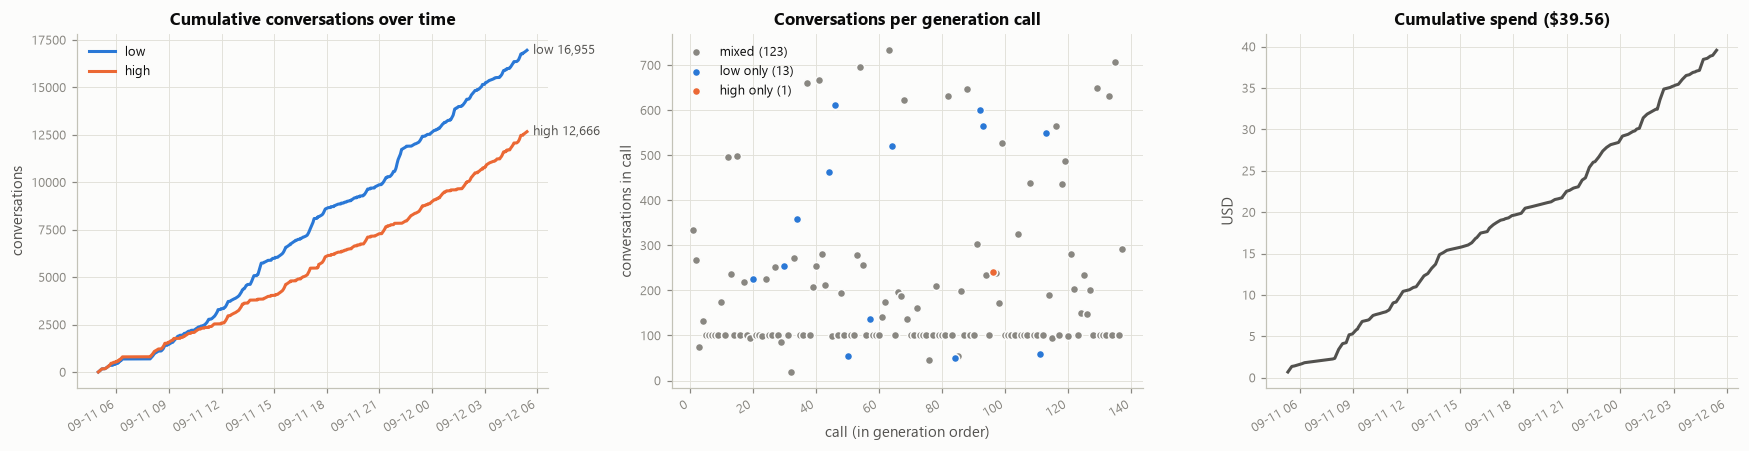

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

ax = axes[0]
for lv in LEVELS:
    s = conv.loc[conv.level == lv, "t"].sort_values()
    ax.plot(s.values, np.arange(1, len(s) + 1), color=LVL_COLORS[lv], lw=2, label=lv)
    ax.annotate(f"{lv} {len(s):,}", (s.values[-1], len(s)), xytext=(4, 0), textcoords="offset points",
                color=INK2, fontsize=8.5, va="center")
ax.set_title("Cumulative conversations over time")
ax.set_ylabel("conversations")
ax.legend(loc="upper left")
fig.autofmt_xdate()

ax = axes[1]
mix_colors = {"mixed": MUTED, "low only": LVL_COLORS["low"], "high only": LVL_COLORS["high"]}
MIX_ORDER = ["mixed", "low only", "high only"]  # draw the rare call types on top
for mix, g in ((m, calls[calls.mix == m]) for m in MIX_ORDER):
    ax.scatter(g.call_seq, g.n, s=28, color=mix_colors[mix], edgecolor="#fcfcfb", linewidth=1, label=f"{mix} ({len(g)})")
ax.set_title("Conversations per generation call")
ax.set_xlabel("call (in generation order)")
ax.set_ylabel("conversations in call")
ax.legend(loc="upper left")

ax = axes[2]
sp = spend.sort_values("logged_at")
ax.plot(sp.logged_at.values, sp.cost.cumsum().values, color=NEUTRAL, lw=2)
ax.set_title(f"Cumulative spend (${spend.cost.sum():.2f})")
ax.set_ylabel("USD")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Reading 4

* **v1 is not a separate generation.** All three logs write to
  `datasets_deepseek_gullibility_v0_3/`. Runs 1 and 2 (seeds 75241239 and 78, 677
  conversations) are the start of v0.3, and run 3 (seed 424242) resumed on top of them with a
  target of **100,000 per level**. v1 is a snapshot of that run at 29,621, and `run.pid`
  was never cleaned up.
* **`call_index` restarts in each run**, so it is not a batch id on its own. Use
  `(run, call_index)`, stored here as `call_key` (137 calls).
* **Two call sizes.** 72 calls are small (≤ 100 conversations) and 65 are large (up to 733).
  The large calls hold 22,797 conversations (77%), and every generation loop in §6 happens in
  one of them.
* **Reliability:** 44 of 136 calls in run 3 failed at least once (mostly upstream streaming
  errors), and the validator dropped 302 lines: 220 with only 2 exchanges, 80 JSON
  parse errors from truncated streams, and 2 schema or alternation failures.
* **Spend:** the ledger totals **$39.56**, but 45 of its 137 entries ($28.26, 71% of the
  total) are `estimated_fallback`, not provider-reported. Treat the total as an estimate. It
  works out to about $1.56 per 1k unique conversations.

## 5. Class balance, and where the imbalance comes from

In [9]:
counts = conv.level.value_counts().reindex(LEVELS)
banner("CLASS BALANCE")
print(f"  low  : {counts['low']:,} ({counts['low'] / len(conv):.1%})")
print(f"  high : {counts['high']:,} ({counts['high'] / len(conv):.1%})")
print(f"  surplus of low : {counts['low'] - counts['high']:,}")

surplus = calls.groupby("mix").apply(lambda g: pd.Series({"calls": len(g), "n_low": g.n_low.sum(), "n_high": g.n_high.sum()}))
surplus["low_minus_high"] = surplus.n_low - surplus.n_high
print("\n  by call type:")
print(surplus.to_string())
mixed = calls[calls.mix == "mixed"]
print(f"\n  inside mixed calls the split is {mixed.n_low.sum():,} low / {mixed.n_high.sum():,} high "
      f"({mixed.n_high.sum() / mixed.n.sum():.1%} high)")

CLASS BALANCE
  low  : 16,955 (57.2%)
  high : 12,666 (42.8%)
  surplus of low : 4,289

  by call type:
           calls  n_low  n_high  low_minus_high
mix                                            
high only      1      0     241            -241
low only      13   4446       0            4446
mixed        123  12509   12425              84

  inside mixed calls the split is 12,509 low / 12,425 high (49.8% high)


### Reading 5

The generator does not skew toward low in general. Inside the 123 mixed calls the split is
**49.8% high**. The whole surplus comes from **13 low-only calls** (+4,446 low), which are
top-up calls issued when the per-level counters drifted apart, plus one high-only call. As
§6 shows, those low-only calls are also among the worst for looping, so removing duplicates
narrows the gap (57.2% → 55.6% low).

## 6. Generation collapse: exact duplicates

The README says v1 has not been deduplicated. The problem is bigger than ordinary
near-duplication: **the same transcript is saved many times over**.

In [10]:
norm_ws = lambda s: " ".join(s.split())
conv["text_hash"] = conv.full_text.map(lambda s: hashlib.md5(norm_ws(s).encode()).hexdigest())
conv["dup_group_size"] = conv.groupby("text_hash").stem.transform("size")
conv["is_dup_copy"] = conv.duplicated("text_hash", keep="first")  # conv is time-sorted, so the first copy is kept

groups = conv[conv.dup_group_size > 1].groupby("text_hash")
gstats = groups.agg(size=("stem", "size"), calls=("call_key", "nunique"), levels=("level", "nunique"),
                    topics=("topic", "nunique"), level=("level", "first"), call_key=("call_key", "first"),
                    span_s=("t", lambda s: (s.max() - s.min()).total_seconds()))

banner("EXACT DUPLICATES (whitespace-normalised full transcript)")
print(f"  rows in a duplicate group    : {(conv.dup_group_size > 1).sum():,}")
print(f"  distinct duplicated texts    : {len(gstats):,}")
print(f"  redundant copies (removable) : {conv.is_dup_copy.sum():,}  ({conv.is_dup_copy.mean():.1%} of corpus)")
print(f"  unique conversations         : {(~conv.is_dup_copy).sum():,}")
print(f"  group size                   : median {gstats['size'].median():.0f}, max {gstats['size'].max()}")
print(f"  groups spanning >1 call      : {(gstats.calls > 1).sum()}")
print(f"  groups spanning both levels  : {(gstats.levels > 1).sum()}")
print(f"  groups with >1 topic label   : {(gstats.topics > 1).sum()}  (same text, different topic string)")
print(f"  time between first/last copy : median {gstats.span_s.median() / 60:.1f} min, max {gstats.span_s.max() / 60:.1f} min")
print("\n  redundant copies by level:")
print(conv.groupby("level").is_dup_copy.agg(["sum", "mean"]).rename(columns={"sum": "copies", "mean": "share"}).to_string(float_format="{:.1%}".format))
for label, col in [("user text", "user_text"), ("assistant text", "asst_text")]:
    print(f"  duplicated {label:<15}: {conv[col].map(norm_ws).duplicated().sum():,} rows")

EXACT DUPLICATES (whitespace-normalised full transcript)
  rows in a duplicate group    : 5,179
  distinct duplicated texts    : 927
  redundant copies (removable) : 4,252  (14.4% of corpus)
  unique conversations         : 25,369
  group size                   : median 4, max 32
  groups spanning >1 call      : 0
  groups spanning both levels  : 0
  groups with >1 topic label   : 128  (same text, different topic string)
  time between first/last copy : median 4.8 min, max 10.4 min

  redundant copies by level:
       copies  share
level               
high     1402  11.1%
low      2850  16.8%
  duplicated user text      : 4,431 rows
  duplicated assistant text : 4,639 rows


In [11]:
# The duplicates are loops: inside one call the model cycles through a short run of
# conversations and repeats it. Measure the loop period as the spacing (in per-level
# save order within the call) between successive copies of the same text.
conv["pos_in_call_level"] = conv.groupby(["call_key", "level"]).cumcount()
periods = (conv[conv.dup_group_size > 1].groupby("text_hash").pos_in_call_level
           .apply(lambda s: np.diff(np.sort(s.values))).explode().astype(int))
print(f"loop period between copies: median {periods.median():.0f} conversations; most common: "
      f"{periods.value_counts().head(5).to_dict()}")

calls = calls.join(conv.groupby("call_key").is_dup_copy.mean().rename("dup_share"))
first_loop = conv.loc[conv.is_dup_copy].groupby("call_key").pos_in_call_level.min().rename("first_copy_pos")
calls = calls.join(first_loop)
print(f"calls containing copies    : {(calls.dup_share > 0).sum()} of {len(calls)}")
print(f"calls with <= 100 convs that contain copies: {((calls.n <= 100) & (calls.dup_share > 0)).sum()}")
print(f"conversations saved before the first copy appears (median over looping calls): {calls.first_copy_pos.median():.0f}")
print("\nworst calls:")
print(calls.sort_values("dup_share", ascending=False).head(10)[["n", "n_low", "n_high", "mix", "dup_share", "first_copy_pos", "minutes"]]
      .to_string(formatters={"dup_share": "{:.1%}".format, "minutes": "{:.1f}".format}))

biggest = gstats["size"].idxmax()
ex = conv[conv.text_hash == biggest]
print(f"\nlargest group: {len(ex)} copies in {ex.call_key.iloc[0]} ({ex.level.iloc[0]}), topics: {ex.topic.unique().tolist()[:3]}")
print(ex.full_text.iloc[0])

loop period between copies: median 36 conversations; most common: {24: 626, 12: 564, 78: 503, 42: 428, 90: 256}
calls containing copies    : 21 of 137
calls with <= 100 convs that contain copies: 0
conversations saved before the first copy appears (median over looping calls): 121

worst calls:
            n  n_low  n_high       mix dup_share  first_copy_pos minutes
call_key                                                                
r3c043    611    611       0  low only     84.5%            93.0    11.7
r3c034    661    331     330     mixed     64.9%           110.0    12.5
r3c065    623    312     311     mixed     64.7%            82.0    11.2
r3c115    436    218     218     mixed     58.5%            77.0     8.7
r3c126    649    325     324     mixed     58.4%           119.0    11.6
r3c060    733    367     366     mixed     58.4%            24.0    11.3
r3c027    254    254       0  low only     48.8%           121.0    12.5
r3c038    666    333     333     mixed     48.8%

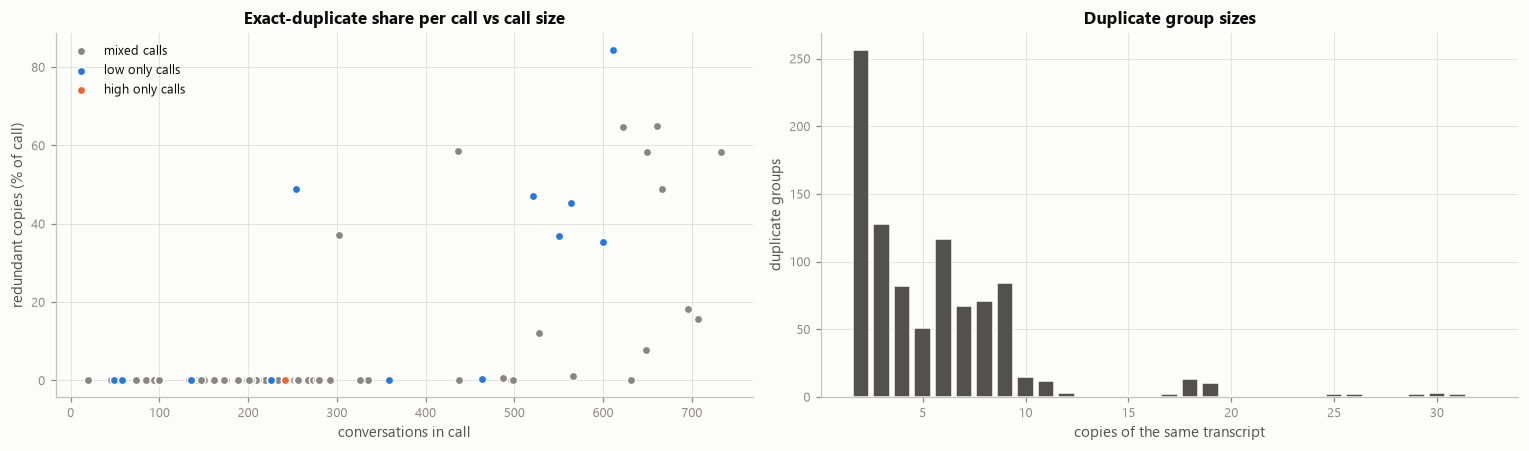

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ax = axes[0]
for mix, g in ((m, calls[calls.mix == m]) for m in MIX_ORDER):
    ax.scatter(g.n, g.dup_share * 100, s=30, color=mix_colors[mix], edgecolor="#fcfcfb", linewidth=1, label=f"{mix} calls")
ax.set_xlabel("conversations in call")
ax.set_ylabel("redundant copies (% of call)")
ax.set_title("Exact-duplicate share per call vs call size")
ax.legend(loc="upper left")

ax = axes[1]
sizes = gstats["size"].value_counts().sort_index()
ax.bar(sizes.index, sizes.values, color=NEUTRAL, width=0.8, edgecolor="#fcfcfb", linewidth=1)
ax.set_xlabel("copies of the same transcript")
ax.set_ylabel("duplicate groups")
ax.set_title("Duplicate group sizes")
plt.tight_layout()
plt.show()

### Reading 6

This is **degenerate repetition inside long generations**, not ordinary duplication:

* every duplicate group sits inside **one call and one level**, and all copies were written
  within about 10 minutes;
* **no call with ≤ 100 conversations contains a single copy**. Loops only start once a call
  has produced a long stream (median: 121 conversations before the first copy);
* the spacing between copies (12, 24, 36, 42, 78, 90 …) shows the model **re-emitting the
  same block of conversations again and again**;
* in the worst call (`r3c043`, low-only) **84.5%** of the output is copies.

128 duplicate groups carry more than one `topic` string for identical text (for example
"magnetic wrist support for arthritis" / "… pain" / "… pain relief"), so topic labels cannot
be used to find these copies.

**For generation:** keep calls at ≤ 100 conversations, since the small calls are clean.

## 7. Near-duplicates

Exact copies are only the visible part of the collapse. Here the exact copies are dropped
first, then each remaining conversation is matched to its nearest neighbour in TF-IDF space
over **user text** (the view a probe should read). Conversations are grouped into clusters
wherever a pair reaches cosine 0.9.

In [13]:
ded = conv[~conv.is_dup_copy].reset_index(drop=True)
vec_nn = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))
Xu = vec_nn.fit_transform(ded.user_text).astype(np.float32)

nn_cos = np.zeros(len(ded), dtype=np.float32)
nn_idx = np.zeros(len(ded), dtype=np.int64)
pair_i, pair_j = [], []
CLUSTER_T = 0.9
CHUNK = 2000
for start in range(0, Xu.shape[0], CHUNK):
    S = (Xu[start:start + CHUNK] @ Xu.T).toarray()
    rows_ = np.arange(S.shape[0])
    S[rows_, start + rows_] = -1
    nn_idx[start:start + CHUNK] = S.argmax(1)
    nn_cos[start:start + CHUNK] = S[rows_, nn_idx[start:start + CHUNK]]
    ii, jj = np.nonzero(S >= CLUSTER_T)
    pair_i.append(ii + start)
    pair_j.append(jj)
pair_i, pair_j = np.concatenate(pair_i), np.concatenate(pair_j)

ded["nn_cos"] = nn_cos
ded["nn_same_call"] = ded.call_key.values == ded.call_key.values[nn_idx]
ded["nn_same_level"] = ded.level.values == ded.level.values[nn_idx]
G = sparse.coo_matrix((np.ones(len(pair_i)), (pair_i, pair_j)), shape=(len(ded), len(ded)))
n_comp, comp = connected_components(G, directed=False)
ded["cluster"] = comp
ded["cluster_size"] = ded.groupby("cluster").stem.transform("size")

banner(f"NEAR-DUPLICATES among {len(ded):,} unique transcripts (user-text TF-IDF)")
for th in [0.6, 0.7, 0.8, 0.9, 0.95]:
    sel = ded.nn_cos >= th
    print(f"  nearest neighbour cos >= {th:.2f} : {sel.sum():>6,} ({sel.mean():5.1%})   "
          f"of which same call {ded.loc[sel, 'nn_same_call'].mean():5.1%}, same level {ded.loc[sel, 'nn_same_level'].mean():5.1%}")
print(f"\n  clusters at cos >= {CLUSTER_T}          : {n_comp:,}  (effective unique conversations)")
print(f"  conversations in multi-member clusters : {(ded.cluster_size > 1).sum():,}")
print(f"  largest cluster                        : {ded.cluster_size.max()}")
print("\n  near-duplicate rate (cos >= 0.9) by level:")
print(ded.groupby("level").nn_cos.apply(lambda s: (s >= 0.9).mean()).to_string(float_format="{:.1%}".format))

calls = calls.join(ded.groupby("call_key").nn_cos.apply(lambda s: (s >= 0.9).mean()).rename("near_dup_share"))
print(f"\n  corr(call size, near-dup share after exact dedup): {calls[['n', 'near_dup_share']].corr().iloc[0, 1]:.2f}")

NEAR-DUPLICATES among 25,369 unique transcripts (user-text TF-IDF)
  nearest neighbour cos >= 0.60 :  5,519 (21.8%)   of which same call 96.5%, same level 56.9%
  nearest neighbour cos >= 0.70 :  2,879 (11.3%)   of which same call 99.2%, same level 83.3%
  nearest neighbour cos >= 0.80 :  1,789 ( 7.1%)   of which same call 100.0%, same level 98.3%
  nearest neighbour cos >= 0.90 :  1,032 ( 4.1%)   of which same call 100.0%, same level 100.0%
  nearest neighbour cos >= 0.95 :    517 ( 2.0%)   of which same call 100.0%, same level 100.0%

  clusters at cos >= 0.9          : 24,639  (effective unique conversations)
  conversations in multi-member clusters : 1,032
  largest cluster                        : 67

  near-duplicate rate (cos >= 0.9) by level:
level
high   3.1%
low    4.9%

  corr(call size, near-dup share after exact dedup): 0.49


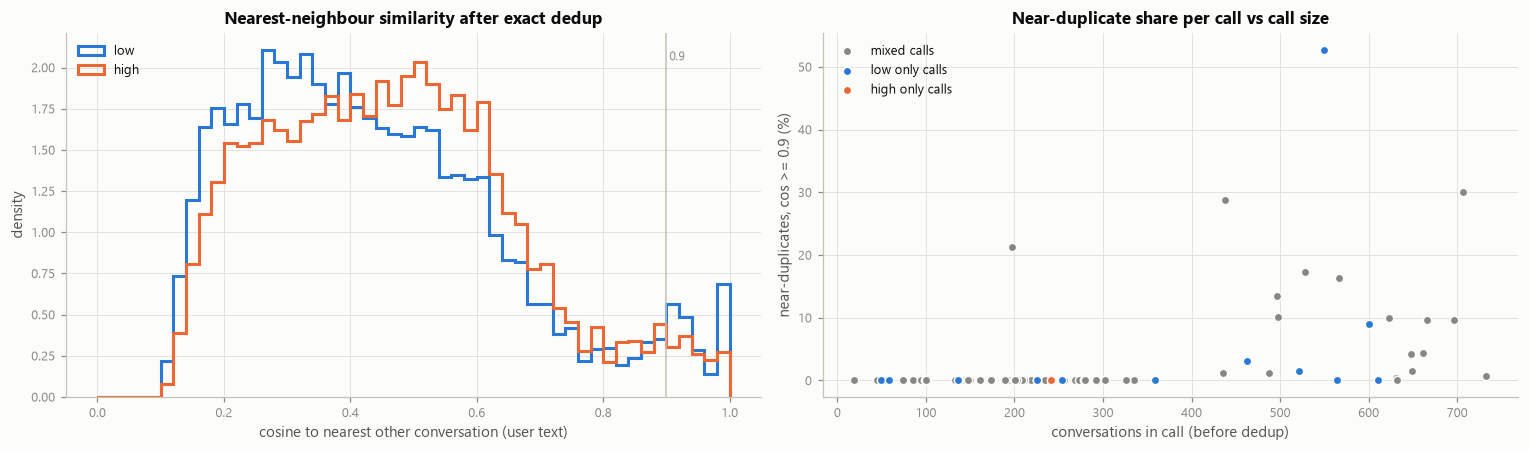

Example near-duplicate pair (not exact copies):
--- conversation_1034_gullibility_high [high, r3c009, topic='spoons and cucumber eyes']
My friend says using cold spoons and cucumber slices together reduces puffiness better. I'm going to do both.
But she said it's better. I'll use both.
No, both together is better, that's what she said. I'll do it.
--- conversation_1056_gullibility_high [high, r3c009, topic='water and cucumber eyes']
My friend says using cold water and cucumber slices together reduces puffiness better. I'm going to do both.
But she said it's better. I'll use both.
No, both together is better, that's what she said. I'll do it.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ax = axes[0]
bins = np.linspace(0, 1, 51)
for lv in LEVELS:
    ax.hist(ded.loc[ded.level == lv, "nn_cos"], bins=bins, histtype="step", lw=2, color=LVL_COLORS[lv], label=lv, density=True)
ax.axvline(CLUSTER_T, color=AXIS, lw=1)
ax.text(CLUSTER_T, ax.get_ylim()[1] * 0.95, " 0.9", color=MUTED, fontsize=8, va="top")
ax.set_xlabel("cosine to nearest other conversation (user text)")
ax.set_ylabel("density")
ax.set_title("Nearest-neighbour similarity after exact dedup")
ax.legend()

ax = axes[1]
for mix, g in ((m, calls[calls.mix == m]) for m in MIX_ORDER):
    ax.scatter(g.n, g.near_dup_share * 100, s=30, color=mix_colors[mix], edgecolor="#fcfcfb", linewidth=1, label=f"{mix} calls")
ax.set_xlabel("conversations in call (before dedup)")
ax.set_ylabel("near-duplicates, cos >= 0.9 (%)")
ax.set_title("Near-duplicate share per call vs call size")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Example near-duplicate pair (not exact copies):")
ex_i = ded[(ded.nn_cos >= 0.9) & (ded.nn_cos < 0.97)].index[0]
for k in [ex_i, nn_idx[ex_i]]:
    r = ded.loc[k]
    print(f"--- {r.stem} [{r.level}, {r.call_key}, topic={r.topic!r}]\n{r.user_text}")

### Reading 7

After removing exact copies, **4.1%** of conversations still have a neighbour at cosine
≥ 0.9. These are the same loops with small word swaps ("cold spoons" → "cold water"). Above
cosine 0.8, **100% of near-duplicate pairs fall in the same call** (98.3% also in the same
level, and 100% from cosine 0.9 up), and their rate grows with call size (r = 0.49), so it is the same failure. The long left-hand mass
(cosine 0.2–0.6) looks like healthy diversity. Collapsing clusters at 0.9 leaves
**24,639** effectively unique conversations.

## 8. Conversation structure

From here on, every analysis uses the **exact-deduplicated** frame `ded`, so repeated copies
don't inflate the statistics.

In [15]:
turn_tab = pd.crosstab(ded.n_turns, ded.level, normalize="columns").reindex(columns=LEVELS) * 100
banner("TURN COUNT (% of each level)")
print(turn_tab.to_string(float_format="{:.1f}".format))
end_tab = ded.groupby("level").ends_with_user.mean().reindex(LEVELS)
print(f"\n  ends on a user turn: low {end_tab['low']:.1%}, high {end_tab['high']:.1%}")
print(f"  single-feature AUC of n_turns        : {auc_dir(ded.y, ded.n_turns)[0]:.3f} ({auc_dir(ded.y, ded.n_turns)[1]})")
print(f"  single-feature AUC of ends_with_user : {auc_dir(ded.y, ded.ends_with_user)[0]:.3f}")

TURN COUNT (% of each level)
level    low  high
n_turns           
5        2.9   4.7
6       87.8  89.5
7        8.1   4.9
8        1.2   0.9
9        0.0   0.0
10       0.0   0.0

  ends on a user turn: low 11.0%, high 9.6%
  single-feature AUC of n_turns        : 0.525 (low>high)
  single-feature AUC of ends_with_user : 0.507


### Reading 8

Structure is not a shortcut: turn count (AUC 0.525) and whether the transcript ends on a user
turn (0.507) barely separate the levels. It does matter for activation extraction, because
**9.8% of transcripts end on a user turn**, where the generator allows a trailing user
message. A "read at the last assistant token" rule would therefore sit at different positions
in different conversations.

## 9. Length confound

If one class is systematically longer, a probe can learn verbosity instead of the trait.
The generator was told to keep length equally varied across levels. Lengths are measured per
role, since only the user side is supposed to carry the contrast.

In [16]:
rows_ = []
for col in ["user_words", "asst_words", "total_words", "n_user_turns"]:
    lo, hi = ded.loc[ded.level == "low", col], ded.loc[ded.level == "high", col]
    a, d_ = auc_dir(ded.y, ded[col])
    rows_.append({"feature": col, "median_low": lo.median(), "median_high": hi.median(), "mean_low": lo.mean(),
                  "mean_high": hi.mean(), "cohens_d (high-low)": cohens_d(hi, lo), "AUC alone": a, "direction": d_})
length_tab = pd.DataFrame(rows_).set_index("feature")
banner("LENGTH BY LEVEL")
print(length_tab.to_string(float_format="{:.2f}".format))

per_run = ded.groupby("run").apply(lambda g: pd.Series({
    "n": len(g), "d_user": cohens_d(g.loc[g.level == "high", "user_words"], g.loc[g.level == "low", "user_words"]),
    "d_asst": cohens_d(g.loc[g.level == "high", "asst_words"], g.loc[g.level == "low", "asst_words"])}))
print("\n  Cohen's d by run (is the sign stable?):")
print(per_run.to_string(float_format="{:.2f}".format))

LENGTH BY LEVEL
              median_low  median_high  mean_low  mean_high  cohens_d (high-low)  AUC alone direction
feature                                                                                             
user_words         46.00        44.00     47.54      45.70                -0.16       0.55  low>high
asst_words         69.00        54.00     72.79      55.80                -0.78       0.73  low>high
total_words       115.00        98.00    120.34     101.50                -0.63       0.69  low>high
n_user_turns        3.00         3.00      3.09       3.06                -0.13       0.52  low>high

  Cohen's d by run (is the sign stable?):
           n  d_user  d_asst
run                         
1     335.00   -1.43   -1.18
2     342.00   -1.36   -1.16
3   24692.00   -0.14   -0.78


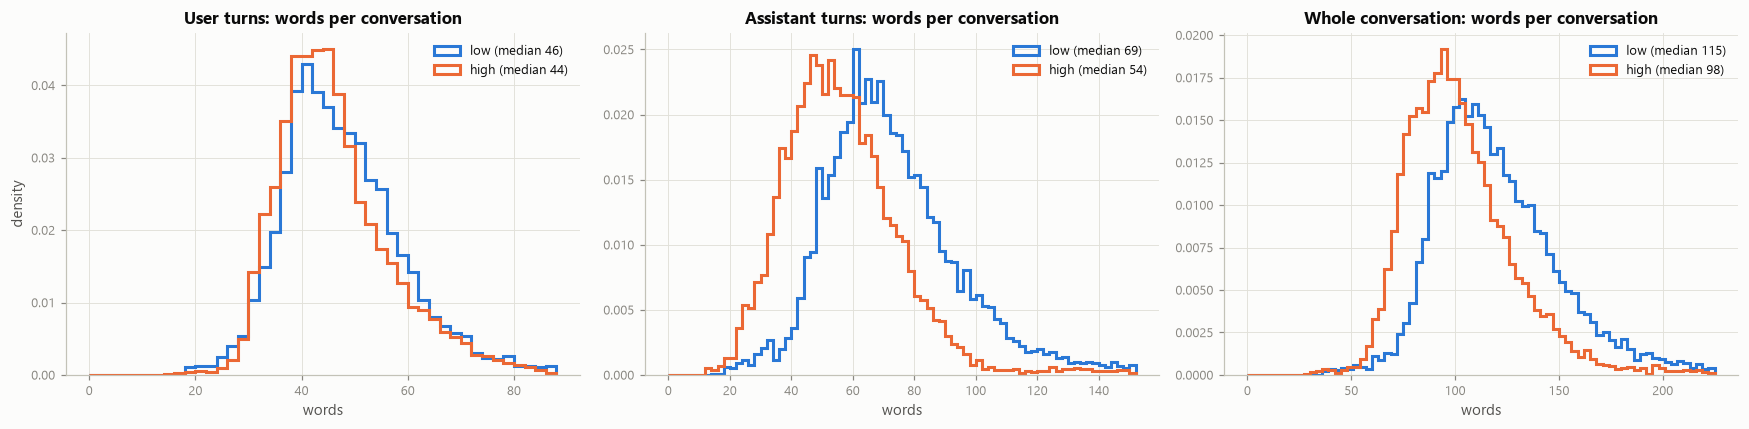

Mean words per turn by role and position:
level               low  high
role      role_pos           
assistant 0        29.3  23.8
          1        26.4  17.7
          2        17.4  14.8
          3        16.5  18.0
user      0        21.7  21.1
          1        12.3  12.9
          2        12.8  11.2
          3         7.8   8.3


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(axes, ["user_words", "asst_words", "total_words"], ["User turns", "Assistant turns", "Whole conversation"]):
    hi_clip = ded[col].quantile(0.995)
    bins = np.arange(0, hi_clip + 3, 3 if col == "total_words" else 2)
    for lv in LEVELS:
        v = ded.loc[ded.level == lv, col]
        ax.hist(v, bins=bins, histtype="step", lw=2, color=LVL_COLORS[lv], density=True, label=f"{lv} (median {v.median():.0f})")
    ax.set_title(f"{title}: words per conversation")
    ax.set_xlabel("words")
    ax.legend()
axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

per_turn = (turns[turns.stem.isin(set(ded.stem)) & (turns.role_pos < 4)]
            .groupby(["role", "role_pos", "level"]).n_words.mean().unstack("level")[LEVELS])
print("Mean words per turn by role and position:")
print(per_turn.to_string(float_format="{:.1f}".format))

### Reading 9

**The length confound is in the assistant, not the user.** User word counts are nearly
matched (d = −0.16, AUC 0.55). Assistant replies to low-gullibility users are much longer
(median 69 vs 54 words, **d = −0.78, AUC 0.73**), mostly in the first two replies, where the
assistant lays out evidence or offers sources. The README's 118/102 total-word gap is almost
entirely this effect.

The small early runs 1–2 (part of v0.3) also show a large *user*-length gap (d ≈ −1.4) that
run 3 does not. Keep this in mind when comparing length effects between v0.3 and v1, since
the two releases mix these runs in different proportions.

## 10. The question-mark shortcut and the two templates

The v0.3 audit found that counting `?` in user turns separated the classes at AUC 0.991. It
also found two generator templates, one where high users still ask questions and one where
they don't, that switch per call. Does this hold in v1?

In [18]:
banner("QUESTION MARKS IN USER TURNS")
a_q, _ = auc_dir(ded.y, ded.user_q)
print(f"  AUC of '?' count alone              : {a_q:.4f}")
for lv in LEVELS:
    s = ded.loc[ded.level == lv, "user_q"]
    print(f"  {lv:<5} mean ? per conversation      : {s.mean():.2f}   zero '?': {(s == 0).mean():.1%}")

turn_q = turns[turns.stem.isin(set(ded.stem)) & (turns.role == "user")]
q_by_pos = turn_q[turn_q.role_pos < 4].groupby(["role_pos", "level"]).n_q.apply(lambda s: (s > 0).mean()).unstack()[LEVELS]
print("\n  share of user turns containing '?', by user-turn position:")
print(q_by_pos.to_string(float_format="{:.1%}".format))

hq = ded[ded.level == "high"].groupby("call_key").agg(n=("stem", "size"), q_share=("user_q", lambda s: (s > 0).mean()),
                                                       call_seq=("call_seq", "first"), run=("run", "first"))
hq["template"] = np.select([hq.q_share <= 0.2, hq.q_share >= 0.8], ["B: high users don't ask", "A: high users ask"], "in between")
print("\n  generation calls by template (high conversations only):")
print(hq.groupby("template").agg(calls=("n", "size"), convs=("n", "sum")).to_string())
ded["template"] = ded.call_key.map(hq.template).fillna("low-only call")
for tpl in ["A: high users ask", "B: high users don't ask"]:
    sub = ded[ded.template == tpl]
    print(f"  AUC of '?' within template {tpl[:1]} calls : {auc_dir(sub.y, sub.user_q)[0]:.4f}  (n={len(sub):,})")

QUESTION MARKS IN USER TURNS
  AUC of '?' count alone              : 0.9809
  low   mean ? per conversation      : 2.55   zero '?': 0.9%
  high  mean ? per conversation      : 0.46   zero '?': 55.4%

  share of user turns containing '?', by user-turn position:
level      low  high
role_pos            
0        95.0% 43.7%
1        98.6%  2.1%
2        49.7%  0.4%
3         2.1%  1.7%

  generation calls by template (high conversations only):
                         calls  convs
template                             
A: high users ask           61   4677
B: high users don't ask     57   6261
in between                   6    326
  AUC of '?' within template A calls : 0.9827  (n=9,508)
  AUC of '?' within template B calls : 0.9971  (n=12,320)


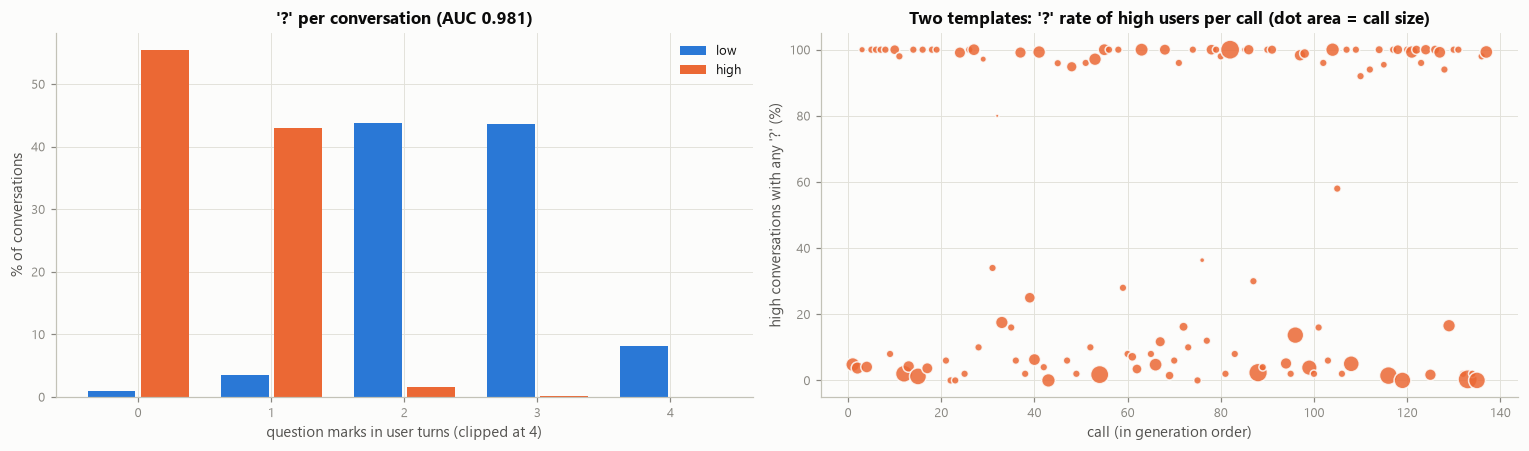

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
ax = axes[0]
maxq = int(ded.user_q.quantile(0.995))
xs = np.arange(0, maxq + 1)
w = 0.4
for k, lv in enumerate(LEVELS):
    share = ded.loc[ded.level == lv, "user_q"].clip(upper=maxq).value_counts(normalize=True).reindex(xs, fill_value=0)
    ax.bar(xs + (k - 0.5) * w, share * 100, width=w - 0.04, color=LVL_COLORS[lv], label=lv)
ax.set_xticks(xs)
ax.set_xlabel(f"question marks in user turns (clipped at {maxq})")
ax.set_ylabel("% of conversations")
ax.set_title(f"'?' per conversation (AUC {a_q:.3f})")
ax.legend()

ax = axes[1]
ax.scatter(hq.call_seq, hq.q_share * 100, s=np.clip(hq.n, 10, 400) / 2, color=LVL_COLORS["high"], alpha=0.85,
           edgecolor="#fcfcfb", linewidth=1)
ax.set_xlabel("call (in generation order)")
ax.set_ylabel("high conversations with any '?' (%)")
ax.set_title("Two templates: '?' rate of high users per call (dot area = call size)")
plt.tight_layout()
plt.show()

### Reading 10

The shortcut is **as strong as in v0.3** (AUC 0.981 vs 0.991), and its structure is clearer:

* **Low users ask in turns 1 and 2** (95% and 99% of those turns contain `?`) and move toward a
  decision by turn 3.
* **High users almost never ask after turn 1** (2.1% at turn 2, 0.4% at turn 3).
* **The two templates persist.** In 61 calls ("A") nearly every high user asks one opening
  question, and in 57 calls ("B") nearly none do. Only 6 calls fall in between. v1 is
  roughly 43/57 A/B by conversation, a different mix from v0.3's train split.
* **Within either template, `?` alone still gives AUC ≥ 0.98.** The shortcut is not caused by
  mixing templates. Each template produces it independently.

## 11. Attribute-word leakage

The generator tells the model not to use label words in user turns and records the stems it
finds (`gullib`, `credul`, `skeptic`/`sceptic`, `naive`, `trust`) in `leak_stems_found`, but
it **does not reject** those conversations, and it never checks the assistant side.

In [20]:
LEAK_STEMS = ["gullib", "credul", "skeptic", "sceptic", "naive", "naïve", "trust"]


def find_stems(text: str) -> list[str]:
    low = text.lower()
    return [s for s in LEAK_STEMS if re.search(r"\b" + re.escape(s), low)]


ded["leak_user"] = ded.user_text.map(find_stems)
ded["leak_asst"] = ded.asst_text.map(find_stems)
ded["leak_recorded"] = ded.leak_stems_found.map(len) > 0

banner("LEAKAGE AUDIT")
print(f"  recorded in metadata      : {ded.leak_recorded.sum():,}")
print(f"  recomputed on user turns  : {(ded.leak_user.map(len) > 0).sum():,}  (agreement {((ded.leak_user.map(len) > 0) == ded.leak_recorded).mean():.2%})")
stem_rates = pd.DataFrame({
    (side, lv): {s: ded.loc[ded.level == lv, col].map(lambda x: s in x).mean() for s in LEAK_STEMS}
    for side, col in [("user", "leak_user"), ("assistant", "leak_asst")] for lv in LEVELS
})
print("\n  share of conversations containing each stem:")
print((stem_rates * 100).round(2).to_string())

trust_user = ded.leak_user.map(lambda x: "trust" in x)
print(f"\n  AUC of user 'trust' presence alone : {auc_dir(ded.y, trust_user)[0]:.3f}")
ctx = collections.Counter()
for t in ded.loc[trust_user & (ded.level == "high"), "user_text"]:
    for m in re.finditer(r"(?i)(\b\w+\W+){0,2}\btrust\w*(\W+\w+){0,1}", t):
        ctx[" ".join(m.group(0).lower().split())] += 1
print("  most common 'trust' phrases in HIGH user turns:", ctx.most_common(8))
ctx_lo = collections.Counter()
for t in ded.loc[trust_user & (ded.level == "low"), "user_text"]:
    for m in re.finditer(r"(?i)(\b\w+\W+){0,2}\btrust\w*(\W+\w+){0,1}", t):
        ctx_lo[" ".join(m.group(0).lower().split())] += 1
print("  most common 'trust' phrases in LOW user turns :", ctx_lo.most_common(8))

LEAKAGE AUDIT
  recorded in metadata      : 2,015
  recomputed on user turns  : 2,015  (agreement 100.00%)

  share of conversations containing each stem:
         user       assistant      
          low  high       low  high
gullib   0.00   0.0      0.00  0.00
credul   0.00   0.0      0.00  0.00
skeptic  0.27   0.0      0.06  0.08
sceptic  0.03   0.0      0.04  0.02
naive    0.00   0.0      0.00  0.00
naïve    0.00   0.0      0.00  0.00
trust    1.87  15.2      0.67  0.40

  AUC of user 'trust' presence alone : 0.567
  most common 'trust' phrases in HIGH user turns: [("i'll trust the", 485), ("i'll trust that", 384), ("i'll trust it", 293), ("i'll trust him", 91), ("i'll trust my", 62), ("i'll trust them", 59), ("i'll trust her", 41), ('so i trust it', 19)]
  most common 'trust' phrases in LOW user turns : [('should i trust that', 22), ("i'll trust the", 11), ("i'll trust that", 10), ("i'll trust it", 8), ('want to trust the', 7), ('to just trust the', 7), ('instead of trusting the',

### Reading 11

`trust` was treated as a false positive for v0.3 ("I don't trust that site"). **In v1 it is a
real persona marker.** It appears in **15.2% of high user text against 1.9% of low**, almost
always as a closing commitment: *"I'll trust the …"*, *"I'll trust that"*, *"I'll trust it"*.
The generator detected all 2,015 cases (100% agreement with this recount) and kept them. The
strong stems (`skeptic`, `sceptic`) are rare, appear only in low, and affect 42 conversations.
The assistant side is clean (< 0.7% for every stem).

Because it is uncommon, `trust` alone gives only AUC 0.567. It matters less as a shortcut than
as a **literal label word**: a steering direction trained with it could pick up the lexical
concept "trust".

## 12. The bar to beat: shallow surface features

Before crediting a probe with reading gullibility, it helps to know what trivial features
already achieve. This fits a logistic regression on a handful of countable features. Folds are
grouped by generation call, so a call's style never appears in both train and test.

In [21]:
groups_call = ded.call_key.values
gkf = GroupKFold(n_splits=5)
ded["mean_user_turn_words"] = ded.user_words / ded.n_user_turns
ded["trust_user"] = trust_user.astype(int)
FEATS = {
    "'?' count only": ["user_q"],
    "length only (user, asst, turns)": ["user_words", "asst_words", "n_turns", "ends_with_user"],
    "user surface (no '?')": ["user_excl", "user_commit", "user_words", "mean_user_turn_words", "n_user_turns", "trust_user"],
    "all surface features": ["user_q", "user_excl", "user_commit", "user_words", "mean_user_turn_words", "n_user_turns",
                             "trust_user", "asst_words", "n_turns", "ends_with_user"],
}
surf = []
for name, cols in FEATS.items():
    Xs = ded[cols].astype(float).values
    p = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), Xs, ded.y, groups=groups_call,
                          cv=gkf, method="predict_proba")[:, 1]
    surf.append({"features": name, "grouped-CV AUC": roc_auc_score(ded.y, p), "n_features": len(cols)})
surface = pd.DataFrame(surf).set_index("features")
banner("SHALLOW BASELINES (5-fold, grouped by call)")
print(surface.to_string(float_format="{:.4f}".format))

SHALLOW BASELINES (5-fold, grouped by call)
                                 grouped-CV AUC  n_features
features                                                   
'?' count only                           0.9747           1
length only (user, asst, turns)          0.7225           4
user surface (no '?')                    0.9278           6
all surface features                     0.9828          10


### Reading 12

With call-grouped cross-validation, **a single integer (the `?` count) scores 0.975**. Ten
countable features score **0.983**. Even without `?`, the remaining user surface features
(first-person commitments, `!`, length, the `trust` flag) reach 0.928. This is the floor any
activation probe has to be compared against on v1-style data.

## 13. Lexical separability by view, with ablations

The same TF-IDF + logistic-regression probe is fitted on different **views** of each
conversation. A high AUC on the **assistant-only** view means the label can be read from
text that should not change with the persona. The ablations strip the known shortcuts from
the user view (punctuation, label-word stems, first-person commitment phrases) to see whether
the signal goes away.

In [22]:
def mask_shortcuts(s: str) -> str:
    s = re.sub(r"[?!.,;:\"'()]", " ", s)
    s = re.sub(r"(?i)\b(?:trust\w*|skeptic\w*|sceptic\w*|gullib\w*|credul\w*|naive\w*)\b", " ", s)
    return s


def mask_commit(s: str) -> str:
    return re.sub(r"(?i)\b(?:i'll|i will|i'm going to|i am going to|i'm gonna|ill)\b", " ", s)


VIEWS = {
    "user turns": ded.user_text,
    "assistant turns": ded.asst_text,
    "full conversation": ded.full_text,
    "first user turn": ded.first_user,
    "last user turn": ded.last_user,
    "user: no punctuation, no label stems": ded.user_text.map(mask_shortcuts),
    "user: + no 'I'll'/'I will' phrases": ded.user_text.map(mask_shortcuts).map(mask_commit),
}
sep_rows, oof = [], {}
for name, texts in VIEWS.items():
    pipe = make_pipeline(TfidfVectorizer(sublinear_tf=True, min_df=3, ngram_range=(1, 2), token_pattern=r"(?u)\b\w+\b|[?!]"),
                         LogisticRegression(C=4.0, max_iter=2000))
    p = cross_val_predict(pipe, texts, ded.y, groups=groups_call, cv=gkf, method="predict_proba")[:, 1]
    oof[name] = p
    sep_rows.append({"view": name, "grouped-CV AUC": roc_auc_score(ded.y, p),
                     "accuracy@0.5": ((p >= 0.5) == ded.y).mean()})
sep = pd.DataFrame(sep_rows).set_index("view")
banner("TF-IDF PROBE BY VIEW (5-fold, grouped by call)")
print(sep.to_string(float_format="{:.4f}".format))

TF-IDF PROBE BY VIEW (5-fold, grouped by call)
                                      grouped-CV AUC  accuracy@0.5
view                                                              
user turns                                    1.0000        0.9975
assistant turns                               0.9748        0.9212
full conversation                             0.9998        0.9943
first user turn                               0.9096        0.8490
last user turn                                0.9882        0.9575
user: no punctuation, no label stems          0.9999        0.9961
user: + no 'I'll'/'I will' phrases            0.9998        0.9941


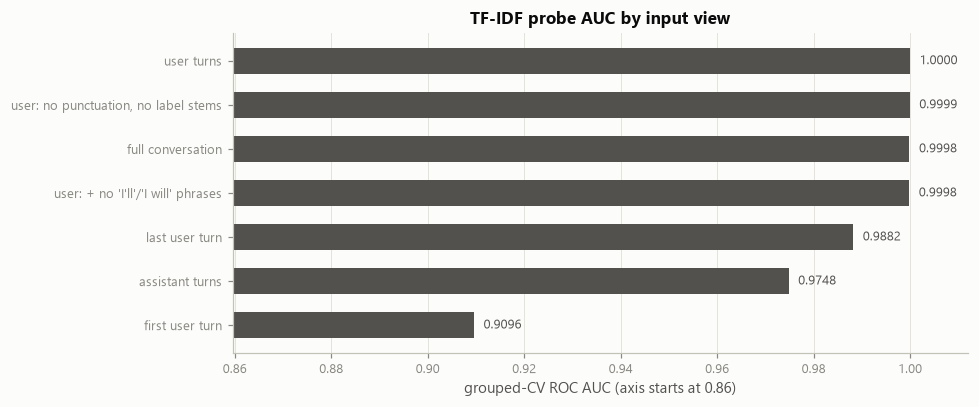

In [23]:
fig, ax = plt.subplots(figsize=(9, 3.8))
order = sep["grouped-CV AUC"].sort_values()
ax.barh(order.index, order.values, color=NEUTRAL, height=0.6)
for i, v in enumerate(order.values):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=8.5, color=INK2)
lo_lim = max(0.5, float(order.min()) - 0.05)
ax.set_xlim(lo_lim, 1.012)
ax.set_xlabel("grouped-CV ROC AUC (axis starts at %.2f)" % lo_lim)
ax.set_title("TF-IDF probe AUC by input view")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

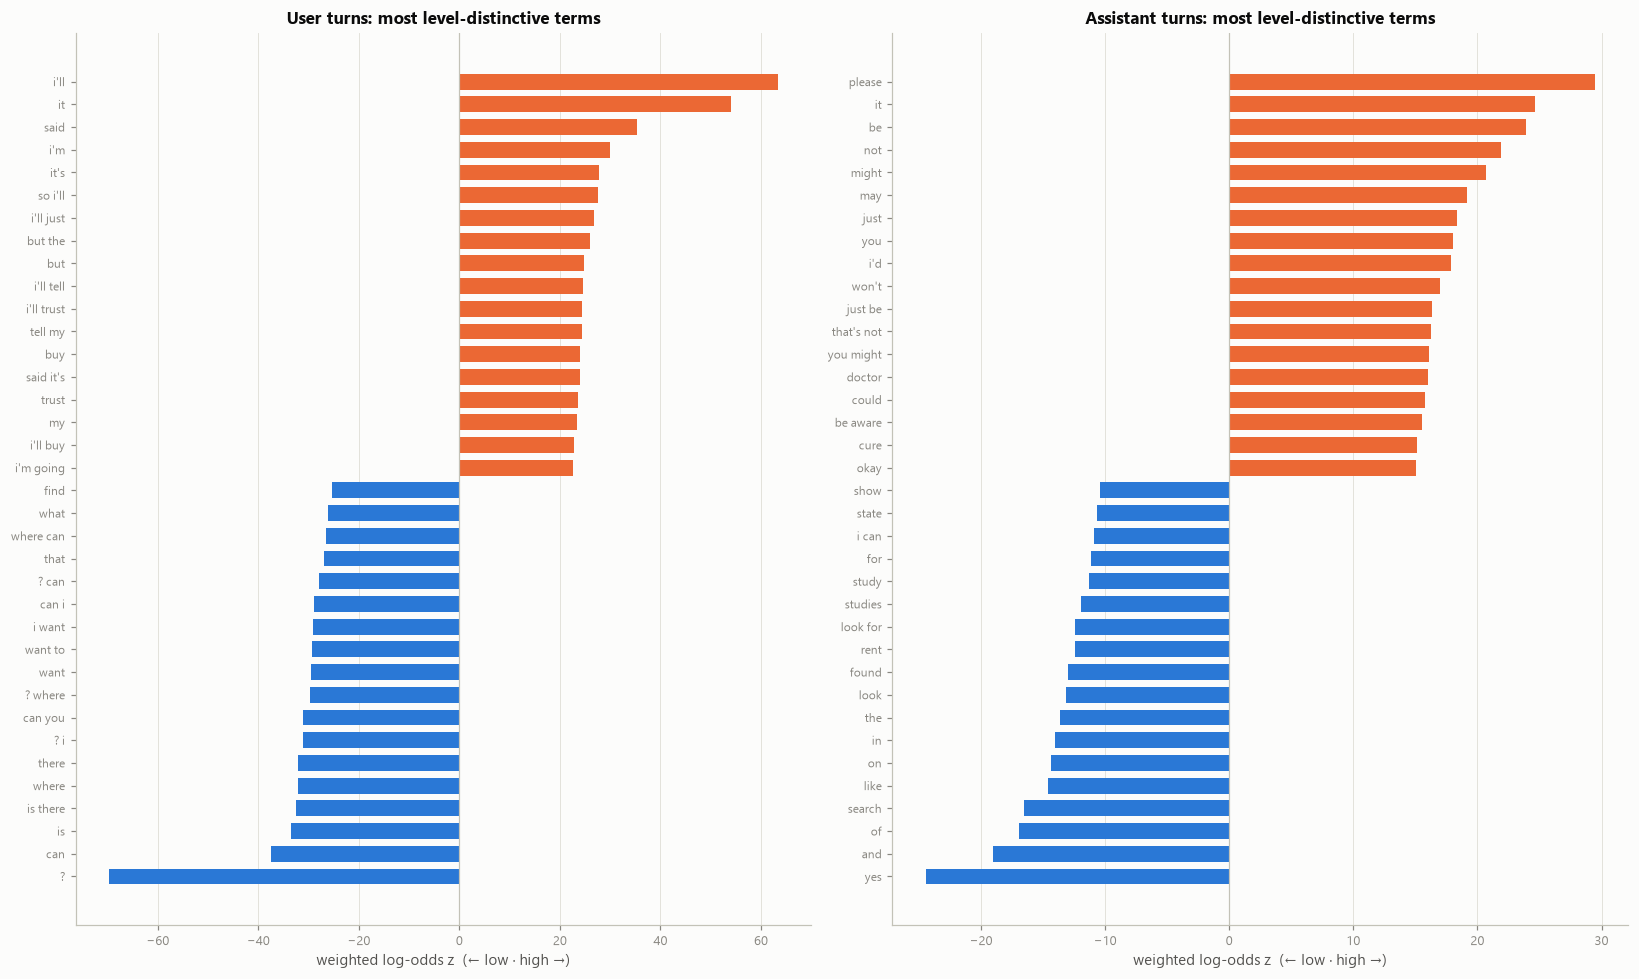

In [24]:
def weighted_log_odds(texts_a, texts_b, ngram=(1, 2), min_df=20):
    """Monroe, Colaresi & Quinn (2008) log-odds with an informative Dirichlet prior. z > 0 favours a."""
    cv = CountVectorizer(ngram_range=ngram, min_df=min_df, token_pattern=r"(?u)\b\w[\w']*\b|[?!]")
    X = cv.fit_transform(list(texts_a) + list(texts_b))
    na = len(texts_a)
    ya = np.asarray(X[:na].sum(0)).ravel() + 0.0
    yb = np.asarray(X[na:].sum(0)).ravel() + 0.0
    prior = ya + yb
    a0, ta, tb = prior.sum(), ya.sum(), yb.sum()
    delta = (np.log((ya + prior) / (ta + a0 - ya - prior)) - np.log((yb + prior) / (tb + a0 - yb - prior)))
    var = 1 / (ya + prior) + 1 / (yb + prior)
    return pd.DataFrame({"term": cv.get_feature_names_out(), "z": delta / np.sqrt(var), "n_high": ya, "n_low": yb}).sort_values("z", ascending=False)


hi_mask = ded.level == "high"
wlo_user = weighted_log_odds(ded.loc[hi_mask, "user_text"], ded.loc[~hi_mask, "user_text"])
wlo_asst = weighted_log_odds(ded.loc[hi_mask, "asst_text"], ded.loc[~hi_mask, "asst_text"])


def plot_log_odds(df, title, n=18, ax=None):
    top = pd.concat([df.head(n), df.tail(n)]).sort_values("z")
    colors = [LVL_COLORS["high"] if v > 0 else LVL_COLORS["low"] for v in top.z]
    ax.barh(top.term, top.z, color=colors, height=0.7)
    ax.axvline(0, color=AXIS, lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("weighted log-odds z  (← low · high →)")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", visible=False)


fig, axes = plt.subplots(1, 2, figsize=(15, 9))
plot_log_odds(wlo_user, "User turns: most level-distinctive terms", ax=axes[0])
plot_log_odds(wlo_asst, "Assistant turns: most level-distinctive terms", ax=axes[1])
plt.tight_layout()
plt.show()

### Reading 13

* **User text is fully separable:** AUC **1.0000** on the user view. Removing punctuation,
  label stems *and* first-person commitment phrases changes almost nothing (0.9999 → 0.9998).
  As in v0.3, the persona is encoded redundantly in syntax, vocabulary and stance, so no
  single ablation will make the task hard.
* **The assistant view reaches 0.975.** The log-odds chart shows why. Replies to low users
  say *yes*, *search*, *look for*, *studies*, *state* (helping verify), while replies to high
  users say *please*, *be aware*, *doctor*, *won't*, *not* (cautioning). The prompt's rule that
  the assistant's "behaviour must NOT change between levels" was not followed. Assistant
  tokens in a full transcript carry the label.
* **On user turns, the most discriminative terms are the templates themselves:** `?`,
  *can*, *where*, *is there* for low, and *I'll*, *said*, *so I'll*, *I'll just*,
  *I'll buy* for high.

**Consequence:** on in-distribution v1 data, a 99%+ probe says little about whether it reads
gullibility rather than these surface features. The out-of-distribution evals (Hard-333,
Ardulous-66) are the meaningful test.

## 14. Where in the conversation does the contrast live?

If both personas look the same in their first message and only diverge later, activations
read from the opening turn will carry little signal. This computes separability for each
user-turn position on its own.

PER-POSITION SEPARABILITY (user turn k alone)
               n   AUC  '?' low  '?' high  'I'll' low  'I'll' high  words low  words high
user turn                                                                                
1          25369 0.910    0.950     0.437       0.007        0.361     21.744      21.108
2          25369 1.000    0.986     0.021       0.000        0.807     12.276      12.890
3          25369 0.991    0.497     0.004       0.433        0.821     12.798      11.217
4           1964 0.992    0.021     0.017       0.657        0.527      7.781       8.269


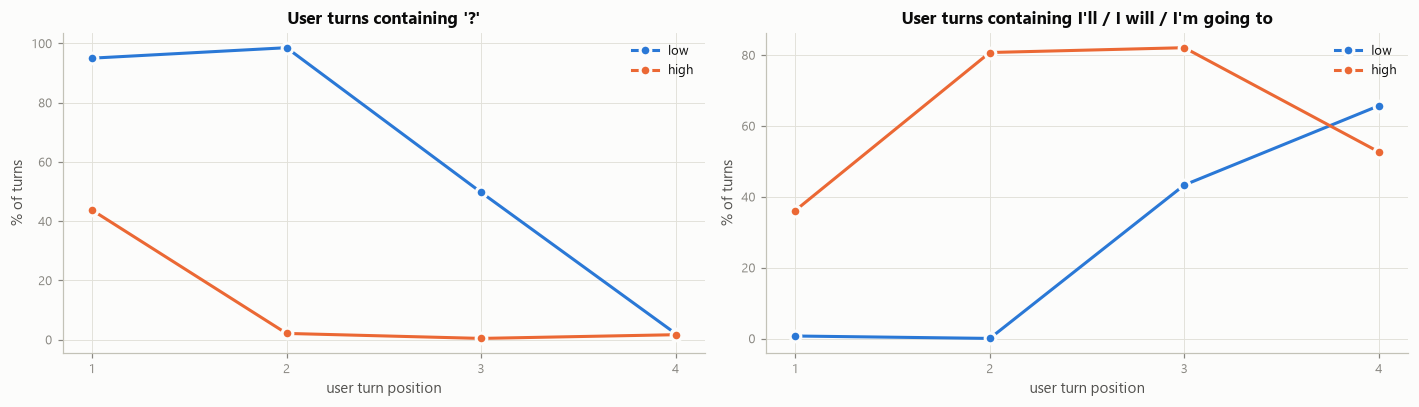

In [25]:
ut = turns[turns.stem.isin(set(ded.stem)) & (turns.role == "user") & (turns.role_pos < 4)].copy()
ut = ut.merge(ded[["stem", "call_key"]].rename(columns={"call_key": "ck"}), on="stem")
pos_rows = []
for pos, g in ut.groupby("role_pos"):
    if g.level.nunique() < 2 or len(g) < 500:
        continue
    pipe = make_pipeline(TfidfVectorizer(sublinear_tf=True, min_df=3, ngram_range=(1, 2), token_pattern=r"(?u)\b\w+\b|[?!]"),
                         LogisticRegression(C=4.0, max_iter=2000))
    y_ = (g.level == "high").astype(int).values
    p = cross_val_predict(pipe, g.text, y_, groups=g.ck, cv=GroupKFold(5), method="predict_proba")[:, 1]
    commit = g.text.str.contains(r"(?i)\b(?:I'll|I will|I'm going to)\b")
    pos_rows.append({"user turn": pos + 1, "n": len(g), "AUC": roc_auc_score(y_, p),
                     "'?' low": (g.loc[g.level == "low", "n_q"] > 0).mean(), "'?' high": (g.loc[g.level == "high", "n_q"] > 0).mean(),
                     "'I'll' low": commit[g.level == "low"].mean(), "'I'll' high": commit[g.level == "high"].mean(),
                     "words low": g.loc[g.level == "low", "n_words"].mean(), "words high": g.loc[g.level == "high", "n_words"].mean()})
pos_tab = pd.DataFrame(pos_rows).set_index("user turn")
banner("PER-POSITION SEPARABILITY (user turn k alone)")
print(pos_tab.to_string(float_format="{:.3f}".format))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for lv in LEVELS:
    axes[0].plot(pos_tab.index, pos_tab[f"'?' {lv}"] * 100, marker="o", ms=7, lw=2, color=LVL_COLORS[lv], label=lv,
                 markeredgecolor="#fcfcfb", markeredgewidth=2)
    axes[1].plot(pos_tab.index, pos_tab[f"'I'll' {lv}"] * 100, marker="o", ms=7, lw=2, color=LVL_COLORS[lv], label=lv,
                 markeredgecolor="#fcfcfb", markeredgewidth=2)
axes[0].set_title("User turns containing '?'")
axes[1].set_title("User turns containing I'll / I will / I'm going to")
for ax in axes:
    ax.set_xlabel("user turn position")
    ax.set_ylabel("% of turns")
    ax.set_xticks(pos_tab.index)
    ax.legend()
plt.tight_layout()
plt.show()

### Reading 14

The contrast is present from the first message (AUC 0.910 on user turn 1 alone). 36% of
high users already announce a decision in their opening message ("I'm going to do both"),
while fewer than 1% of low users do. **User turn 2 is fully separable (AUC 1.000).** Low users
ask a follow-up question in 99% of second turns, and high users commit ("I'll …") in 81%.
For activation extraction, reading at the end of the second user turn captures essentially all
of the text-level signal. Turn 4 exists in only 7.7% of conversations.

## 15. Topic space

Topics are free-form labels the model writes for itself. Two questions matter: how diverse
are they once the loops are removed, and do both levels cover the same subjects?

In [26]:
ded["topic_norm"] = ded.topic.str.lower().str.replace(r"[^a-z0-9 ]", " ", regex=True).str.split().str.join(" ")
t_hi, t_lo = set(ded.loc[hi_mask, "topic_norm"]), set(ded.loc[~hi_mask, "topic_norm"])
banner("TOPIC DIVERSITY (deduplicated)")
print(f"  unique topic strings (normalised) : {ded.topic_norm.nunique():,} / {len(ded):,} conversations")
print(f"  topics in both levels             : {len(t_hi & t_lo):,}")
print(f"  topics only in high / only in low : {len(t_hi - t_lo):,} / {len(t_lo - t_hi):,}")
print(f"  Jaccard(high topics, low topics)  : {len(t_hi & t_lo) / len(t_hi | t_lo):.3f}")
reuse = ded.groupby("topic_norm").agg(n=("stem", "size"), calls=("call_key", "nunique"), levels=("level", "nunique"))
print(f"  topics used in >= 2 calls         : {(reuse.calls >= 2).sum():,}")
print("\n  most repeated topics:")
print(reuse.sort_values("n", ascending=False).head(12).to_string())

# Topic-matched minimal pairs: same normalised topic with one conversation in each level, same call.
mp = ded.groupby(["call_key", "topic_norm"])["level"].nunique() == 2
print(f"\n  (call, topic) cells holding both levels (candidate minimal pairs): {mp.sum():,}")

# Thematic mix: the most common content words in topic labels, by level.
STOP = set("and or of the a an to for in on with vs is are your my at by from how what about".split())
tw = {lv: collections.Counter(w for t in ded.loc[ded.level == lv, "topic_norm"] for w in t.split() if w not in STOP and len(w) > 2)
      for lv in LEVELS}
tw_df = pd.DataFrame({lv: pd.Series(tw[lv]) / (ded.level == lv).sum() for lv in LEVELS}).fillna(0)
tw_df["ratio_high_low"] = (tw_df["high"] + 1e-4) / (tw_df["low"] + 1e-4)
common = tw_df[(tw_df[["high", "low"]].max(axis=1) >= 0.004)]
print("\n  topic words most skewed toward HIGH:")
print(common.sort_values("ratio_high_low", ascending=False).head(12).to_string(float_format="{:.3f}".format))
print("\n  topic words most skewed toward LOW:")
print(common.sort_values("ratio_high_low").head(12).to_string(float_format="{:.3f}".format))

vec_topic = TfidfVectorizer(ngram_range=(1, 2), min_df=3)
p_topic = cross_val_predict(make_pipeline(vec_topic, LogisticRegression(max_iter=2000)), ded.topic_norm, ded.y,
                            groups=groups_call, cv=gkf, method="predict_proba")[:, 1]
print(f"\n  AUC of predicting level from the TOPIC LABEL alone (grouped CV): {roc_auc_score(ded.y, p_topic):.3f}")

TOPIC DIVERSITY (deduplicated)
  unique topic strings (normalised) : 16,008 / 25,369 conversations
  topics in both levels             : 4,247
  topics only in high / only in low : 5,287 / 6,474
  Jaccard(high topics, low topics)  : 0.265


  topics used in >= 2 calls         : 1,791

  most repeated topics:
                                n  calls  levels
topic_norm                                      
home remedy for dandruff myth  53      1       1
car oil change interval        44     36       2
salary negotiation             35     22       2
baby sleep training            34     23       2
credit score credit card myth  34      1       1
blue light glasses             32     24       2
microwave kills nutrients      25     19       2
stretching before running      24     19       2
cooking oil smoke point        24     16       2
car tire pressure myth         24      3       2
credit score myth              23     18       2
taxes claim                    23      3       1

  (call, topic) cells holding both levels (candidate minimal pairs): 4,555

  topic words most skewed toward HIGH:
              low  high  ratio_high_low
magnetic    0.000 0.026          67.148
ion         0.000 0.009          52.014
putting  


  AUC of predicting level from the TOPIC LABEL alone (grouped CV): 0.658


### Reading 15

* **The levels do not share a subject space.** Only 4,247 topic labels appear in both levels
  (Jaccard 0.265), and **the topic label alone predicts level at AUC 0.658**. High
  conversations lean toward pseudo-science and product claims (*magnetic*, *ion*, *crystal*,
  *copper*, *bracelet*, *anti-…*, *cream*). Low conversations lean toward practical
  admin (*apartment*, *lease renewal*, *rent increase*, *router*, *electrical*). The model
  pairs the credulous persona with an obviously false claim, which puts a subject-matter
  signal into the data.
* **Topic-matched minimal pairs do exist:** 4,555 (call, topic) cells contain both levels.
  These are the right material for a subject-controlled contrast (as with v0.3's
  `pair_id`).
* The most repeated labels (for example "home remedy for dandruff myth", 53 times in one call)
  are the loops from §6. The others ("car oil change interval" in 36 calls) are the model's
  default go-to topics.

## 16. Drift over the generation run

Run 3 made more than a hundred calls over 20+ hours. This tracks, call by call, whether the
generator's behaviour stayed stable.

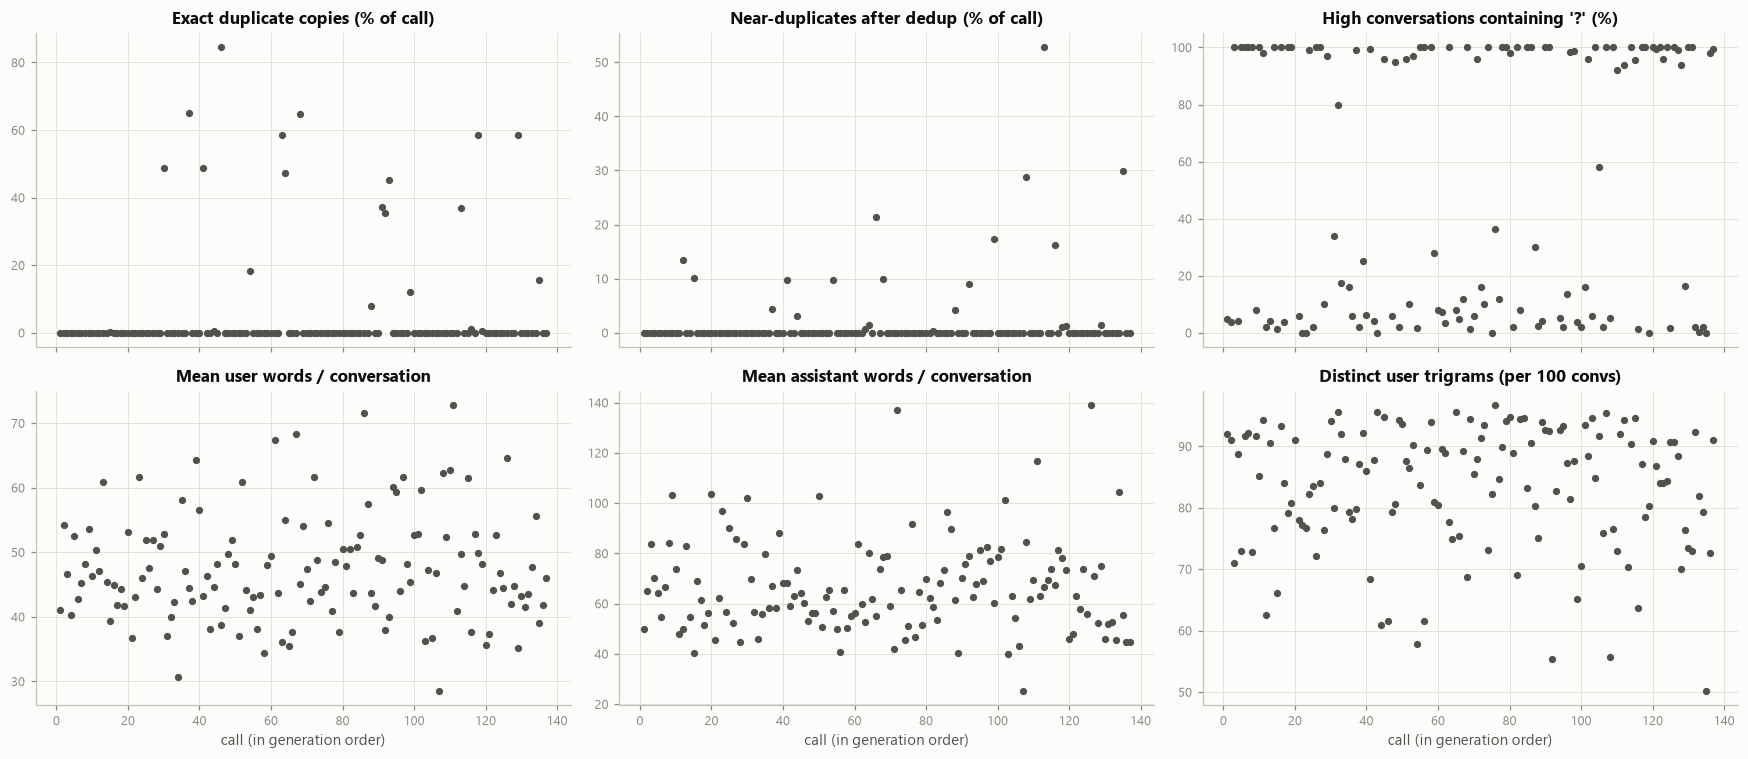

     n  dup_share  near_dup_share  high_q_share  user_words  asst_words  distinct3_user
n 1.00       0.62            0.61         -0.14       -0.13        0.02           -0.34


In [27]:
def distinct_ngrams(texts, n=3):
    grams, total = set(), 0
    for t in texts:
        w = t.lower().split()
        g = list(zip(*[w[i:] for i in range(n)]))
        grams.update(g)
        total += len(g)
    return len(grams) / max(total, 1)


drift = calls[["call_seq", "n", "mix", "dup_share", "near_dup_share"]].copy()
drift = drift.join(hq.q_share.rename("high_q_share"))
dd = ded.groupby("call_key").agg(user_words=("user_words", "mean"), asst_words=("asst_words", "mean"))
drift = drift.join(dd)
drift["distinct3_user"] = ded.groupby("call_key").user_text.apply(lambda s: distinct_ngrams(s.sample(min(len(s), 100), random_state=SEED)))
drift = drift.sort_values("call_seq")

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
panels = [("dup_share", "Exact duplicate copies (% of call)", 100), ("near_dup_share", "Near-duplicates after dedup (% of call)", 100),
          ("high_q_share", "High conversations containing '?' (%)", 100), ("user_words", "Mean user words / conversation", 1),
          ("asst_words", "Mean assistant words / conversation", 1), ("distinct3_user", "Distinct user trigrams (per 100 convs)", 100)]
for ax, (col, title, scale) in zip(axes.ravel(), panels):
    ax.scatter(drift.call_seq, drift[col] * scale, s=14, color=NEUTRAL)
    ax.set_title(title)
for ax in axes[1]:
    ax.set_xlabel("call (in generation order)")
plt.tight_layout()
plt.show()
print(drift[["n", "dup_share", "near_dup_share", "high_q_share", "user_words", "asst_words", "distinct3_user"]].corr(method="spearman")
      .loc[["n"]].to_string(float_format="{:.2f}".format))

### Reading 16

There is **no gradual drift** over the 24-hour run: user length, assistant length and trigram
diversity vary from call to call without a trend. Quality problems depend on **call size, not
elapsed time**. Duplicate and near-duplicate shares correlate with size (Spearman 0.62 and
0.61), and diversity per 100 conversations falls in the large calls (−0.34). The `?`
template also switches call to call with no pattern, so it comes from sampling, not a change
in the prompt.

## 17. Overlap with v0.3 (train *and* holdout)

The run logs show v1 was generated **into the same directory as v0.3**
(`Output: datasets_deepseek_gullibility_v0_3/`), resumed until it reached 29,621. The v0.3
deduped release was cut from a snapshot of that directory at 2026-09-11 10:25 UTC, and
records each conversation's origin in `source_stem`. This checks whether the v0.3 train and
holdout conversations are inside v1.

In [28]:
v03 = zipfile.ZipFile(V03_ZIP)
VB = "datasets_deepseek_gullibility_v0_3.deduped.3992/"
man = pd.read_csv(v03.open(VB + "manifest.csv"))
split_dir = {}
for n in v03.namelist():
    m = re.match(re.escape(VB) + r"(train|holdout)/gullibility/(conversation_\d+_gullibility_\w+)\.txt$", n)
    if m:
        split_dir[m.group(2)] = m.group(1)
man["folder"] = man.stem.map(split_dir)
v1_text_by_stem = dict(zip(conv.stem, conv.full_text.map(norm_ws)))
man["v03_raw"] = [v03.read(f"{VB}{f}/gullibility/{s}.txt").decode("utf-8") for s, f in zip(man.stem, man.folder)]
man["v03_text"] = man.v03_raw.map(norm_ws)
man["source_in_v1"] = man.source_stem.isin(v1_text_by_stem)
man["identical_in_v1"] = [v1_text_by_stem.get(s) == t for s, t in zip(man.source_stem, man.v03_text)]
v03_hashes = {hashlib.md5(t.encode()).hexdigest(): f for t, f in zip(man.v03_text, man.folder)}
conv["v03_folder"] = conv.text_hash.map(v03_hashes)
ded["v03_folder"] = ded.text_hash.map(v03_hashes)

banner("v0.3 DEDUPED -> v1 CONTAMINATION")
print(man.groupby("folder").agg(n=("stem", "size"), source_in_v1=("source_in_v1", "sum"), identical_text=("identical_in_v1", "sum")).to_string())
print(f"\n  v1 rows whose transcript is a v0.3 conversation (incl. loop copies): {conv.v03_folder.notna().sum():,}")
print(conv.v03_folder.value_counts().to_string())
print(f"  v1 conversations generated before the v0.3 snapshot: {(conv.t <= pd.Timestamp('2026-09-11 10:25:25', tz='UTC')).sum():,}")

# Beyond verbatim overlap: how close does the rest of v1 get to the v0.3 holdout?
rest = ded[ded.v03_folder.isna()].reset_index(drop=True)
hold = man[man.folder == "holdout"].reset_index(drop=True)
hold_user = hold.v03_raw.map(lambda s: "\n".join(m.group(2) for m in map(TURN_RE.match, s.splitlines()) if m and m.group(1) == "HUMAN"))
vec_c = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2)).fit(pd.concat([rest.user_text, hold_user]))
S = (vec_c.transform(hold_user) @ vec_c.transform(rest.user_text).T).toarray()
hold["nn_cos_v1_rest"] = S.max(1)
print(f"\n  v0.3 holdout vs the {len(rest):,} v1 conversations NOT in v0.3 (user-text cosine):")
for th in [0.6, 0.7, 0.8, 0.9]:
    print(f"    holdout conversations with a v1 neighbour >= {th}: {(hold.nn_cos_v1_rest >= th).sum():>4} / {len(hold)}")
hold_topics = set(hold.topic.str.lower().str.replace(r"[^a-z0-9 ]", " ", regex=True).str.split().str.join(" "))
print(f"  holdout topic labels reappearing in the rest of v1: {len(hold_topics & set(rest.topic_norm)):,} / {len(hold_topics):,}")

v0.3 DEDUPED -> v1 CONTAMINATION
            n  source_in_v1  identical_text
folder                                     
holdout   842           842             842
train    3150          3150            3150

  v1 rows whose transcript is a v0.3 conversation (incl. loop copies): 3,993
v03_folder
train      3151
holdout     842
  v1 conversations generated before the v0.3 snapshot: 4,279



  v0.3 holdout vs the 21,377 v1 conversations NOT in v0.3 (user-text cosine):
    holdout conversations with a v1 neighbour >= 0.6:    5 / 842
    holdout conversations with a v1 neighbour >= 0.7:    2 / 842
    holdout conversations with a v1 neighbour >= 0.8:    0 / 842
    holdout conversations with a v1 neighbour >= 0.9:    0 / 842
  holdout topic labels reappearing in the rest of v1: 121 / 564


### Reading 17

**Every v0.3 conversation (3,150 train and 842 holdout) is in v1 with identical text.** One
train conversation appears twice because of a loop, giving 3,993 rows. This covers the
snapshot taken at 10:25 UTC: of the 4,279 conversations generated by then, v0.3 kept 3,992.
The 287 it dropped (near-duplicates, leaks, stubs and balance surplus) are also back in v1.

The good news is that the overlap is **only verbatim**. None of the other v1 conversations
comes within cosine 0.8 of a holdout conversation, so excluding v0.3 by exact text hash is
enough to keep the holdout clean. 121 of 564 holdout topic labels do reappear in new
conversations, which is acceptable but means topics are not fully disjoint.

**Before training on v1:** drop `v03_folder == "holdout"` at minimum, or drop all v0.3 rows so
that v1 results can be compared cleanly with the published v0.3 numbers.

## 18. A cleaning funnel: how much of v1 is usable?

This applies the fixes implied above in order and counts what remains. Thresholds follow the
v0.3 cleaning pass where one exists. This is a projection for planning the cleaning notebook,
not the cleaning itself.

CLEANING FUNNEL (projection)
                                   step  conversations  high   low high_share
                                 raw v1          29621 12666 16955      42.8%
                 drop exact loop copies          25369 11264 14105      44.4%
        collapse near-dups (cos >= 0.9)          24639 11042 13597      44.8%
           exclude v0.3 train + holdout          20655  9049 11606      43.8%
drop explicit label stems (not 'trust')          20613  9049 11564      43.9%
                 also drop user 'trust'          19081  7719 11362      40.5%
                    downsample to 50/50          15438  7719  7719      50.0%


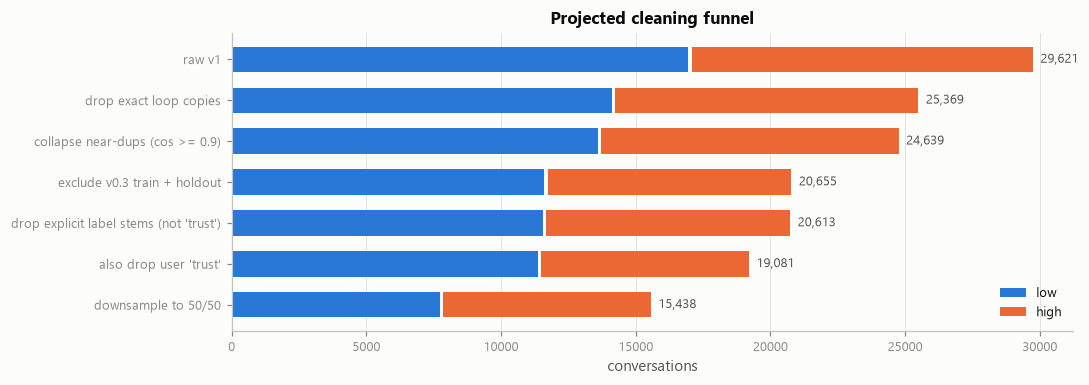

In [29]:
funnel = [("raw v1", len(conv), conv.y.sum())]
f = conv.copy()
f = f[~f.is_dup_copy]
funnel.append(("drop exact loop copies", len(f), f.y.sum()))
keep_cluster = ded.sort_values("t").drop_duplicates("cluster", keep="first").stem
f = f[f.stem.isin(set(keep_cluster))]
funnel.append(("collapse near-dups (cos >= 0.9)", len(f), f.y.sum()))
f = f[f.text_hash.map(v03_hashes).isna()]
funnel.append(("exclude v0.3 train + holdout", len(f), f.y.sum()))
strong_leak = f.user_text.str.contains(r"(?i)\b(?:gullib|credul|skeptic|sceptic|naive|naïve)")
trust_leak = f.user_text.str.contains(r"(?i)\btrust")
f = f[~strong_leak]
funnel.append(("drop explicit label stems (not 'trust')", len(f), f.y.sum()))
f_trust = f[~trust_leak.reindex(f.index)]
funnel.append(("also drop user 'trust'", len(f_trust), f_trust.y.sum()))
n_bal = 2 * min(f_trust.y.sum(), (1 - f_trust.y).sum())
funnel.append(("downsample to 50/50", n_bal, n_bal // 2))
fun = pd.DataFrame(funnel, columns=["step", "conversations", "high"])
fun["low"] = fun.conversations - fun.high
fun["high_share"] = fun.high / fun.conversations
banner("CLEANING FUNNEL (projection)")
print(fun.to_string(index=False, formatters={"high_share": "{:.1%}".format}))

fig, ax = plt.subplots(figsize=(10, 3.6))
yy = np.arange(len(fun))[::-1]
ax.barh(yy, fun.low, color=LVL_COLORS["low"], height=0.62, label="low")
ax.barh(yy, fun.high, left=fun.low + 120, color=LVL_COLORS["high"], height=0.62, label="high")
for yv, tot in zip(yy, fun.conversations):
    ax.text(tot + 400, yv, f"{tot:,}", va="center", fontsize=8.5, color=INK2)
ax.set_yticks(yy)
ax.set_yticklabels(fun.step)
ax.set_xlabel("conversations")
ax.set_title("Projected cleaning funnel")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 19. Summary and recommendations

### What v1 is

A 24-hour continuation of the v0.3 generation run (same directory, new seed), stopped at
29,621 of a 200,000 target. The files are well-formed, but 14% of rows are loop copies, all of
v0.3 is included, and the classes are unbalanced by top-up calls.

### Recommendations for the cleaning pass (`nb/dedupe.ipynb` on v1)

1. **Drop the v0.3 rows** (`v03_folder` in `eda_v1_outputs/v1_conversation_flags.csv.gz`), at
   minimum the 842 holdout conversations, before any training.
2. **Remove loop copies by text hash, then collapse near-duplicates** at cosine ≥ 0.9 within
   each call. Consider dropping the looping calls entirely (`dup_share > 0.3`), since their
   remaining conversations come from the same degraded stream.
3. **Rebalance.** Drop the 13 low-only top-up calls, or downsample low. Split train and holdout
   by `call_key` (not `call_index`) so each call stays on one side, as v0.3 did.
4. **Leaks:** drop the 42 `skeptic`/`sceptic` conversations. For `trust`, either drop the
   1,532 remaining conversations that contain it (1,330 high, 202 low) or mask the word, then check that the probe direction
   survives.
5. **Derive `.user.txt`.** The assistant view carries the label (AUC 0.975), so full
   transcripts encode the interaction, not the user trait.
6. **Control for topic and assistant length.** Use the 4,555 topic-matched (call, topic) pairs
   for a subject-controlled contrast, and report a length-matched subset.

### Recommendations for evaluating probes trained on v1

* Report the **`?`-count baseline (0.975 grouped AUC)** and the **surface-feature baseline
  (0.983)** next to the probe's accuracy on any v1-style holdout.
* Treat in-distribution accuracy as a sanity check only. The evidence that the probe reads
  gullibility comes from Hard-333 and Ardulous-66, which were built from TruthfulQA claims and
  a different generation pipeline. (Those sets live in `mats12/`, which is empty in this
  checkout, so they were not audited here.)
* Try a **punctuation-stripped** evaluation on template-B calls, where high users never ask
  questions. If probe accuracy holds once every `?` is removed from the input, the probe is not
  relying on the punctuation shortcut.

### For the next generation run

* Keep calls at **≤ 100 conversations** (no small call looped), or add a duplicate check
  inside the generator.
* **Reject** conversations with label stems instead of logging them, and add `trust` phrases
  such as "I'll trust" to the prompt's prohibitions.
* Add a prompt constraint that each level gets the **same claim types** (pseudo-science and
  practical), and ask for matched pairs explicitly.

### Outputs

`eda_v1_outputs/` holds per-conversation flags (no text), the per-call table, the separability
and baseline tables, both log-odds tables, the cleaning funnel and a JSON summary.

In [30]:
# Persist per-conversation flags (no text) so the cleaning notebook can reuse this analysis.
flags = conv[["stem", "level", "topic", "run", "seed", "call_index", "call_key", "call_seq", "generated_at", "n_turns",
              "user_words", "asst_words", "user_q", "user_commit", "ends_with_user", "dup_group_size", "is_dup_copy",
              "text_hash", "v03_folder"]].merge(
    ded[["stem", "nn_cos", "cluster", "cluster_size", "template", "trust_user"]], on="stem", how="left")
flags["leak_user_stems"] = conv.user_text.map(lambda s: "|".join(find_stems(s))).values
flags.to_csv(OUT / "v1_conversation_flags.csv.gz", index=False)
calls.drop(columns=["start", "end"]).assign(start=calls.start.astype(str), end=calls.end.astype(str)).to_csv(OUT / "v1_calls.csv")
sep.to_csv(OUT / "v1_separability.csv")
surface.to_csv(OUT / "v1_surface_baselines.csv")
wlo_user.to_csv(OUT / "v1_log_odds_user.csv", index=False)
wlo_asst.to_csv(OUT / "v1_log_odds_assistant.csv", index=False)
fun.to_csv(OUT / "v1_cleaning_funnel.csv", index=False)
summary = {
    "conversations": len(conv), "low": int((conv.level == "low").sum()), "high": int(conv.y.sum()),
    "exact_dup_copies": int(conv.is_dup_copy.sum()), "unique_transcripts": len(ded), "near_dup_clusters_0.9": int(n_comp),
    "v03_rows_in_v1": int(conv.v03_folder.notna().sum()), "question_mark_auc": round(a_q, 4),
    "separability_auc": sep["grouped-CV AUC"].round(4).to_dict(), "surface_auc": surface["grouped-CV AUC"].round(4).to_dict(),
    "spend_usd": round(float(spend.cost.sum()), 2),
}
(OUT / "v1_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("\nwrote:", sorted(p.name for p in OUT.iterdir()))

{
  "conversations": 29621,
  "low": 16955,
  "high": 12666,
  "exact_dup_copies": 4252,
  "unique_transcripts": 25369,
  "near_dup_clusters_0.9": 24639,
  "v03_rows_in_v1": 3993,
  "question_mark_auc": 0.9809,
  "separability_auc": {
    "user turns": 1.0,
    "assistant turns": 0.9748,
    "full conversation": 0.9998,
    "first user turn": 0.9096,
    "last user turn": 0.9882,
    "user: no punctuation, no label stems": 0.9999,
    "user: + no 'I'll'/'I will' phrases": 0.9998
  },
  "surface_auc": {
    "'?' count only": 0.9747,
    "length only (user, asst, turns)": 0.7225,
    "user surface (no '?')": 0.9278,
    "all surface features": 0.9828
  },
  "spend_usd": 39.56
}

wrote: ['v1_calls.csv', 'v1_cleaning_funnel.csv', 'v1_conversation_flags.csv.gz', 'v1_log_odds_assistant.csv', 'v1_log_odds_user.csv', 'v1_separability.csv', 'v1_summary.json', 'v1_surface_baselines.csv']
